# **Курсовой проект**


# Описание кейса:

## - Бизнес-контекст
Один из автоцентров холдинга, «Меркур Авто», хочет понять своё положение на рынке и выявить точки роста.

Нам передали данные по всем продажам автомобилей в Казахстане за девять месяцев 2019 года.

Задача — подготовить данные и провести анализ, который поможет менеджменту «Меркур Авто» оценить свою эффективность и принять стратегические решения.

## - Проблема
Данные находятся в типичном для операционных систем состоянии: в них много нестандартных форматов, неявных ошибок и лишней информации. Из-за этого невозможно провести качественный анализ без тщательной предподготовки.

## - Цели
- Техническая цель: довести датасет до состояния, пригодного для анализа. Создать скрипт его очистки для автоматизации обработки похожих данных в будущем.
- Аналитическая цель: провести разведочный анализ (EDA) всего рынка и дать оценку позиции и ключевым показателям эффективности автоцентра «Меркур Авто».

# План работы:
- Загрузка и первичный осмотр данных
- Глубокая очистка и преобразование данных
- Исследовательский анализ данных (EDA)
- Анализ рынка и позиции «Меркур Авто»


## 1. Загрузка и первичный осмотр данных


Импортируем нужные библиотеки

In [1]:
! pip install pycountry
import re
from pandas.tseries.offsets import MonthEnd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload ()

Saving autokz2019.csv to autokz2019 (1).csv


Загружаем данные из CSV-файла

In [3]:
csv_path = 'autokz2019.csv'

sep = ';'
decimal = ','

df = pd.read_csv(csv_path, sep=sep, decimal=decimal, encoding='utf-8')

Выведем первые 5 строк таблицы

In [4]:
print(df.head())

    Год   Месяц     Компания Бренд Модель Модификация Год выпуска  \
0  2019     Май  Mercur Auto  Audi     A3        TFSI        2018   
1  2019  Август  Mercur Auto  Audi     A3        TFSI        2018   
2  2019  Апрель  Mercur Auto  Audi     A4        TFSI        2018   
3  2019    Июль  Mercur Auto  Audi     A4        TFSI        2018   
4  2019    Июль  Mercur Auto  Audi     A4        TFSI        2018   

  Страна-производитель Вид топлива Объём двиг, л,  ... Тип клиента  \
0             Германия      Бензин            1,4  ...   Физ. Лицо   
1             Германия      Бензин            1,4  ...    Юр. Лицо   
2             Германия      Бензин            1,4  ...   Физ. Лицо   
3             Германия      Бензин            1,4  ...    Юр. Лицо   
4             Германия      Бензин            1,4  ...   Физ. Лицо   

  Форма расчета Количество Цена, USD Продажа, USD   Область  \
0   безналичный        1.0  28115.00     28115.00  г.Алматы   
1      наличный        1.0  32246.99  

Проверим размер и типы данных таблицы

In [5]:
print("Размер:", df.shape)
print("\nТипы данных столбцов:\n",df.dtypes)

Размер: (39966, 25)

Типы данных столбцов:
 Год                                 int64
Месяц                              object
Компания                           object
Бренд                              object
Модель                             object
Модификация                        object
Год выпуска                        object
Страна-производитель               object
Вид топлива                        object
Объём двиг, л,                     object
Коробка передач                    object
Тип привода                        object
Сегмент                            object
Регион                             object
Наименование дилерского центра     object
Тип клиента                        object
Форма расчета                      object
Количество                        float64
Цена, USD                         float64
Продажа, USD                      float64
Область                            object
Сегментация 2013                   object
Класс 2013                      

Видим, что Количество не целочисленный тип, а также Год выпуска. Объем двигателя не float.

Посмотрим количество пропусков по столбцам

In [6]:
df.isna().sum().sort_values(ascending=False)


,0
Форма расчета,25928
Тип клиента,7047
Сегмент,6761
Тип привода,4289
"Объём двиг, л,",4258
Модификация,3591
Коробка передач,3255
Вид топлива,3140
Год выпуска,501
Количество,6


Замечаем большое количество пропусков в 9 столбцах, проверим процент пропусков в каждом столбце.

In [7]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False).round(1)

,0
Форма расчета,64.9
Тип клиента,17.6
Сегмент,16.9
Тип привода,10.7
"Объём двиг, л,",10.7
Модификация,9.0
Коробка передач,8.1
Вид топлива,7.9
Год выпуска,1.3
Количество,0.0


Видим, что в одном столбце пропусков больше 60 процентов, в остальных столбцах пропусков 1.3-17.6 процентов. Будем работать с ними в следующем пункте.

Таким образом, получена полная картина "сырых" данных. Выявлены ключевые проблемы: некорректные типы данных для числовых признаков и значительные пропуски. Это определяет задачи для следующих этапов: преобразование типов и обработка пропусков.

Удалим ненужные столбцы:  которые не несут аналитической ценности или содержат критичное количество пропусков: Дилер, Тип платежа, Сегмент, Сегмент ЕПР, Локализация, Тип клиента, Модификация

In [8]:
print("\nРазмер до удаления:", df.shape)

cols_to_drop = ['Дилер', 'Наименование дилерского центра', 'Тип платежа', 'Форма расчета', 'Сегмент', 'Сегмент ЕПР', 'Сегментация Eng',
                'Локализация', 'Локализация производства', 'Тип клиента', 'Модификация']
present_to_drop = [c for c in cols_to_drop if c in df.columns]
print("\nБудут удалены столбцы (наличие в df):", present_to_drop)

df.drop(columns=present_to_drop, inplace=True)
print("\nРазмер после удаления:", df.shape)
print("\n Столбцы в таблице:", df.columns)



Размер до удаления: (39966, 25)

Будут удалены столбцы (наличие в df): ['Наименование дилерского центра', 'Форма расчета', 'Сегмент', 'Сегментация Eng', 'Локализация производства', 'Тип клиента', 'Модификация']

Размер после удаления: (39966, 18)

 Столбцы в таблице: Index(['Год', 'Месяц', 'Компания', 'Бренд', 'Модель', 'Год выпуска',
       'Страна-производитель', 'Вид топлива', 'Объём двиг, л,',
       'Коробка передач', 'Тип привода', 'Регион', 'Количество', 'Цена, USD',
       'Продажа, USD', 'Область', 'Сегментация 2013', 'Класс 2013'],
      dtype='object')


Упрощена структура данных, удалены малополезные и сильно неполные признаки. Размер сократился до 18 столбцов, что повысит эффективность последующего анализа. Некоторые указанные в задании столбцы отсутствовали в данных.

Для удобства назовем столбцы по-английски

In [9]:
df.rename(columns={
    'Год': 'year',
    'Месяц': 'month',
    'Компания': 'company',
    'Бренд': 'brand',
    'Модель': 'model',
    'Год выпуска': 'manufacture_year',
    'Страна-производитель': 'manufacture_country',
    'Вид топлива': 'fuel_type',
    'Объём двиг, л,': 'engine_volume',
    'Коробка передач': 'transmission',
    'Тип привода': 'drive_type',
    'Регион': 'region',
    'Количество': 'quantity',
    'Цена, USD': 'price_usd',
    'Продажа, USD': 'sold_price_usd',
    'Область': 'oblast',
    'Сегментация 2013': 'segmentation_2013',
    'Класс 2013': 'class_2013'
}, inplace=True)
df.head()

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
0,2019,Май,Mercur Auto,Audi,A3,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,28115.00,28115.00,г.Алматы,Легковые автомобили,C класс
1,2019,Август,Mercur Auto,Audi,A3,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,32246.99,32246.99,г.Алматы,Легковые автомобили,C класс
2,2019,Апрель,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-Tronic,FWD,Алматы,1.0,32000.00,32000.00,г.Алматы,Легковые автомобили,D класс
3,2019,Июль,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,31929.00,31929.00,г.Алматы,Легковые автомобили,D класс
4,2019,Июль,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,31929.00,31929.00,г.Алматы,Легковые автомобили,D класс


Стандартизированы названия признаков, что улучшает читаемость кода. Теперь названия интуитивно понятны и удобны для использования в коде.

Удаляем полностью пустые строки и явные дубликаты

In [10]:
print("Таблица до очистки:", df.shape)

before_rows = len(df)
df.dropna(how='all', inplace=True)
after_dropna_rows = len(df)
print(f"Удалено полностью пустых строк: {before_rows - after_dropna_rows}")

before_dup = len(df)
df.drop_duplicates(inplace=True)
after_dup = len(df)
print(f"Удалено дубликатов: {before_dup - after_dup}")

print("Таблица после очистки:", df.shape)


Таблица до очистки: (39966, 18)
Удалено полностью пустых строк: 0
Удалено дубликатов: 23471
Таблица после очистки: (16495, 18)


Очистка данных выявила огромное количество дубликатов (~59% от исходного объема). Это важное наблюдение: либо в данных были технические дубли, либо бизнес-процесс генерации данных требует проверки. Финальный объем для анализа — 16,495 уникальных записей.

### Вывод по пункту 1: Загрузка и первичный осмотр данных

Загрузка и первичный осмотр данных выполнены в полном соответствии с планом задания:
- Исходный датасет содержал 39,966 записей и 25 признаков.
- После оценки качества данных были удалены 7 нерелевантных или сильно заполненных пропусками столбцов, а оставшиеся переименованы на английский язык для удобства.
- Очистка от дубликатов выявила и удалила значительное количество повторяющихся записей (23,471), что существенно сократило объем данных до 16,495 уникальных транзакций. Полностью пустых строк не обнаружено.
- Основные проблемы, выявленные на этом этапе и требующие решения на следующих шагах: некорректные типы данных у числовых полей, наличие пропусков в 9 столбцах.


## 2. Глубокая очистка и преобразование данных

### Страна производства

Посмотрим какие значения стран есть

In [11]:
df['manufacture_country'].value_counts(dropna=False)

,count
manufacture_country,
Республика Казахстан,8292
Российская Федерация,5004
Япония,1800
Турция,309
Таиланд,306
Германия,245
США,241
UK,173
Австрия,30


Закодируем названия стран в стандартные трехбуквенные коды ALPHA-3

In [12]:


def to_alpha3(country_name_ru):
    try:
        country = next(
            (c for c in pycountry.countries if c.name.lower() == country_name_ru.lower()),
            None
        )
        if country:
            return country.alpha_3
    except Exception:
        pass
    manual = {
    "Республика Казахстан": "KAZ",
    "Российская Федерация": "RUS",
    "Япония": "JPN",
    "Турция": "TUR",
    "Таиланд": "THA",
    "Германия": "DEU",
    "США": "USA",
    "UK": "GBR",
    "Австрия": "AUT",
    "Китай": "CHN"
    }
    return manual.get(country_name_ru.strip(), None)

df['manufacture_country'] = df['manufacture_country'].apply(to_alpha3)

Проверяем значения

In [13]:
df['manufacture_country'].value_counts(dropna=False)

,count
manufacture_country,
KAZ,8292
RUS,5004
JPN,1800
TUR,309
THA,306
DEU,245
USA,241
GBR,173
None,75


Страны успешно закодированы в международный стандарт (KAZ, RUS, DEU и т.д.), что позволяет однозначно идентифицировать происхождение автомобилей.


### Вид топлива

Посмотрим на уникальные значения

In [14]:
df['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Бензин,14699
NaN,1096
Дизель,602
бензин,53
2,12
дизель,9
"1,6",9
гибрид,8
0,3


Проверим значения 2; 1,6; 0 (может это значения других столбцов)?

In [15]:
df[df['fuel_type'].isin(['2', '1,6', '0'])]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
23723,2019,Январь,Renault Россия,Renault,Duster,2019,RUS,2,MT,4WD,4WD,Уральск,1.0,12249.61125,12249.61125,Западно-Казахстанская область,Внедорожники,Субкомпактные SUV
23724,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,AT,4WD,4WD,Нур-Султан,1.0,12249.61125,12249.61125,г.Нур-Султан,Внедорожники,Субкомпактные SUV
23726,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,AT,4WD,4WD,Кызылорда,1.0,12249.61125,12249.61125,Кызылординская область,Внедорожники,Субкомпактные SUV
23727,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,MT,4WD,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23728,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,"1,6",MT,4WD,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23729,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,AT,4WD,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23734,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,"1,6",AT,Передний,Передний,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23746,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,AT,4WD,4WD,Усть-Каменогорск,1.0,12249.61125,12249.61125,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV
23747,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,MT,4WD,4WD,Усть-Каменогорск,1.0,12249.61125,12249.61125,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV
23748,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,2,AT,4WD,4WD,Шымкент,1.0,12249.61125,12249.61125,Южно-Казахстанская область,Внедорожники,Субкомпактные SUV


Видим, что значения столбцов перепутаны. Сделаем значения 2 и 1,6 и 0 в столбце fuel_type Nan, остальные значения закодируем: F — бензин, D — дизель, E — электро, HYB — гибрид. Перед этим значения 2 и 1,6 перенесем в engine_volume, значения МТ или АТ из engine_volume перенесем в transmission.


In [16]:
problem_rows = df[df['fuel_type'].isin(['2', '1,6', '0'])]

In [17]:
for idx in df.index:
    engine_val = df.at[idx, 'engine_volume']
    if pd.notna(engine_val):
        engine_str = str(engine_val)
        if 'МТ' in engine_str or 'MT' in engine_str:
            df.at[idx, 'transmission'] = 'Механика'
        elif 'АТ' in engine_str or 'AT' in engine_str:
            df.at[idx, 'transmission'] = 'Автомат'

mask_2_16 = df['fuel_type'].isin(['2', '1,6'])
df.loc[mask_2_16, 'engine_volume'] = df.loc[mask_2_16, 'fuel_type'].str.replace(',', '.')

In [18]:
s = df['fuel_type'].astype(str).str.strip().str.lower()

df.loc[s.isin(['2','1,6','1.6','0']), 'fuel_type'] = np.nan
df.loc[s.str.contains('бенз', na=False), 'fuel_type'] = 'F'
df.loc[s.str.contains('дизел', na=False), 'fuel_type'] = 'D'
df.loc[s.str.contains('элек', na=False), 'fuel_type'] = 'E'
df.loc[s.str.contains('гибрид', na=False), 'fuel_type'] = 'HYB'

Проверим эти проблемные строки

In [19]:
after_rows = df.loc[problem_rows.index]
after_rows

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
23723,2019,Январь,Renault Россия,Renault,Duster,2019,RUS,NaN,2,Механика,4WD,Уральск,1.0,12249.61125,12249.61125,Западно-Казахстанская область,Внедорожники,Субкомпактные SUV
23724,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Автомат,4WD,Нур-Султан,1.0,12249.61125,12249.61125,г.Нур-Султан,Внедорожники,Субкомпактные SUV
23726,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Автомат,4WD,Кызылорда,1.0,12249.61125,12249.61125,Кызылординская область,Внедорожники,Субкомпактные SUV
23727,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Механика,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23728,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,1.6,Механика,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23729,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Автомат,4WD,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23734,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,1.6,Автомат,Передний,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23746,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Автомат,4WD,Усть-Каменогорск,1.0,12249.61125,12249.61125,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV
23747,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Механика,4WD,Усть-Каменогорск,1.0,12249.61125,12249.61125,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV
23748,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,2,Автомат,4WD,Шымкент,1.0,12249.61125,12249.61125,Южно-Казахстанская область,Внедорожники,Субкомпактные SUV


Проверяем значения столбца

In [20]:
df['fuel_type'].value_counts(dropna=False)


,count
fuel_type,
F,14752
NaN,1120
D,611
HYB,8
E,4


Типы топлива стандартизированы. Выявлена и исправлена проблема: в некоторых строках в поле fuel_type попали значения объема двигателя (2, 1,6), при этом в engine_volume попали значения типа трансмиссии.


### Тип привода

Посмотрим значения

In [21]:
df['drive_type'].value_counts(dropna=False)


,count
drive_type,
4WD,3852
Передний,2854
2 WD,1689
Полный,1677
NaN,1368
2WD,1296
Задний,932
4 WD,887
FF,613


Проверим строки со значениями Астана, #Н/Д, 0 (вдруг значения столбцов опятть перепутаны?)

In [22]:
df[df['drive_type'].isin(['Астана'])]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
15771,2019,Май,ТК КАМАЗ,KAMAZ,65116,2019,KAZ,D,NaN,MT,Астана,Нур-Султан,1.0,55655.86316,55655.86316,г.Нур-Султан,Коммерческие автомобили,Крупнотоннажные грузовики
39549,2019,Май,ТК КАМАЗ,KAMAZ,45141,2019,KAZ,D,NaN,MT,Астана,Нур-Султан,1.0,53963.81966,53963.81966,г.Нур-Султан,Коммерческие автомобили,Крупнотоннажные грузовики


In [23]:
df[df['drive_type'].isin(['#Н/Д'])]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
31148,2019,Февраль,Toyota Motor Kazakhstan,Toyota,Corolla,2019,TUR,F,#Н/Д,#Н/Д,#Н/Д,Нур-Султан,1.0,42316.46043,42316.46043,г.Нур-Султан,Легковые автомобили,C класс
32670,2019,Апрель,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,#Н/Д,#Н/Д,Алматы,1.0,30870.28194,30870.28194,г.Алматы,Пикапы,Pick-ups
33070,2019,Июль,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,#Н/Д,#Н/Д,Атырау,1.0,27012.45730,27012.45730,Атырауская область,Пикапы,Pick-ups


In [24]:
df[df['drive_type'].isin(['0'])]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
23737,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,NaN,NaN,0,Нур-Султан,1.0,12249.61125,12249.61125,г.Нур-Султан,Внедорожники,Субкомпактные SUV
23741,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,NaN,NaN,0,Караганда,1.0,12249.61125,12249.61125,Карагандинская область,Внедорожники,Субкомпактные SUV
23744,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,NaN,NaN,0,Кызылорда,1.0,12249.61125,12249.61125,Кызылординская область,Внедорожники,Субкомпактные SUV
23756,2019,Январь,Renault Россия,Renault,Duster,2018,RUS,NaN,NaN,NaN,0,Алматы,1.0,12249.61125,12249.61125,г.Алматы,Внедорожники,Субкомпактные SUV
24430,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Караганда,1.0,16240.31523,16240.31523,Карагандинская область,Внедорожники,Субкомпактные SUV
24431,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Нур-Султан,1.0,16240.31523,16240.31523,г.Нур-Султан,Внедорожники,Субкомпактные SUV
24438,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Кызылорда,1.0,16240.31523,16240.31523,Кызылординская область,Внедорожники,Субкомпактные SUV
24442,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Павлодар,1.0,16240.31523,16240.31523,Павлодарская область,Внедорожники,Субкомпактные SUV
24443,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Усть-Каменогорск,1.0,16240.31523,16240.31523,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV
24446,2019,Январь,Renault Россия,Renault,Kaptur,2018,RUS,NaN,NaN,NaN,0,Алматы,1.0,16240.31523,16240.31523,г.Алматы,Внедорожники,Субкомпактные SUV


Приведем к единому формату, удалив неявные дубликаты:

• "4WD", "4 WD", "4x4", "4X4", "4х4", "4Motion", "AWD", "Полный", "полный", "quattro" -> 4WD

• "FWD", "Передний", "передний", "FF", "Передний (FF)" -> FWD

• "RWD", "Задний" -> RWD

• "2WD", "2 WD", "4x2", "4X2", "4х2", "4х2.2" -> 2WD

• NaN, #Н/Д, 0, "Астана" -> пропущенное значение (NaN)

In [25]:
def normalize_drive(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {'#н/д', 'н/д', '0', '', 'nan', 'none','астана'}:
        return np.nan
    s = s.replace('х', 'x')
    if re.search(r'\b(4s*wd|4 wd|4x4|4x4|4motion|aw d|awd|полный|quattro)\b', s):
        return '4WD'
    if re.search(r'\b(2s*wd|2 wd|4x2|4x2.d*|4x2\b)\b', s):
        return '2WD'
    if re.search(r'(передн|\bff\b|\bfwd\b|front)', s):
        return 'FWD'
    if re.search(r'(задн|\brwd\b|rear)', s):
        return 'RWD'
    return s

df['drive_type'] = df['drive_type'].apply(normalize_drive)

Проверяем значения

In [26]:
print(df['drive_type'].value_counts(dropna=False))

drive_type
4WD    7031
FWD    3982
2WD    3003
NaN    1404
RWD    1075
Name: count, dtype: int64


Данные приведены к 4 четким категориям (4WD, FWD, 2WD, RWD) + NaN

### Числовые столбцы

Проверяем какого типа столбцы количества, стоимости, итоговой стоимости.

In [27]:
print(df[['price_usd', 'sold_price_usd','quantity']].dtypes)

price_usd         float64
sold_price_usd    float64
quantity          float64
dtype: object


Столбцы стоимость и итоговая стоимость - уже подходящего типа. Сделаем столбец количество целочисленным

In [28]:
df['quantity'] = df['quantity'].astype('Int64')

Проверяем

In [29]:
print(df[['price_usd', 'sold_price_usd','quantity']].dtypes)

price_usd         float64
sold_price_usd    float64
quantity            Int64
dtype: object


Посмотрим сколько пропусков в данных столбцах

In [30]:
print(df[['price_usd', 'sold_price_usd','quantity']].isna().sum())

price_usd         0
sold_price_usd    0
quantity          6
dtype: int64


Проверим есть ли отрицательные или нулевые значения в количестве.

In [31]:
df[df['quantity']<0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
25728,2019,Август,БИПЭК АВТО,Skoda,Superb,2019,KAZ,F,2,6DSG,4WD,Тараз,-1,35588.25,-35588.25,Жамбылская область,Легковые автомобили,D класс


In [32]:
df[df['quantity'] ==0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013


In [33]:
df[df['quantity']>75]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
16885,2019,Май,БИПЭК АВТО,Lada,4x4,2019,KAZ,F,"1,69",5 МТ,4WD,Тараз,115,9000.00000,1035000.000,Жамбылская область,Внедорожники,Субкомпактные SUV
25555,2019,Июль,БИПЭК АВТО,Skoda,Octavia,2019,KAZ,F,"1,4",6MT,FWD,Тараз,100,18700.00000,1870000.000,Жамбылская область,Легковые автомобили,C класс
38408,2019,Июнь,Volkswagen Group Rus,Volkswagen,Polo,NaN,RUS,NaN,NaN,NaN,NaN,Алматы,79,15967.84791,1261459.985,г.Алматы,Легковые автомобили,B класс


Есть одна строка с отрицательным количеством - это возврат. Также имеются большие оптовые заказы. Нулевого количества нет. Теперь проверим цену:

In [34]:
df[df['price_usd']<0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013


In [35]:
df[df['price_usd'] ==0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013


Нет отрицательной или нулевой цены. Теперь проверим итоговую стоимость:

In [36]:
df[df['sold_price_usd'] < 0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
25728,2019,Август,БИПЭК АВТО,Skoda,Superb,2019,KAZ,F,2,6DSG,4WD,Тараз,-1,35588.25,-35588.25,Жамбылская область,Легковые автомобили,D класс


In [37]:
df[df['sold_price_usd'] ==0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013
16741,2019,Август,БИПЭК АВТО,Kia,Sportage,2019,KAZ,F,"1,999",6АТ,4WD,Караганда,<NA>,20700.0,0.0,Карагандинская область,Внедорожники,Компактные SUV
17368,2019,Август,БИПЭК АВТО,Lada,Granta,2019,KAZ,F,"1,596",AMT,FWD,Алматы,<NA>,7100.0,0.0,г.Алматы,Легковые автомобили,B класс
18676,2019,Август,БИПЭК АВТО,Lada,XRAY,2018,KAZ,F,"1,596",5МТ,FWD,Экибастуз,<NA>,13800.0,0.0,Павлодарская область,Легковые автомобили,B класс
37416,2019,Август,БИПЭК АВТО,UAZ,3909,2018,KAZ,F,"2,693",5МТ,4WD,Алматы,<NA>,11200.0,0.0,г.Алматы,Коммерческие автомобили,Развозные автомобили
37727,2019,Август,БИПЭК АВТО,UAZ,Patriot,2018,KAZ,F,"2,693",5МТ,4WD,Семей,<NA>,13800.0,0.0,Восточно-Казахстанская область,Внедорожники,Среднеразмерные SUV
38775,2019,Август,БИПЭК АВТО,Skoda,Kodiaq,2019,KAZ,F,2,7DSG,4WD,Нур-Султан,<NA>,40000.0,0.0,г.Нур-Султан,Внедорожники,Полноразмерные SUV


Есть отрицательная итоговая стоимость (вместе с отрицательным количеством) - это скорее всего возврат. А нулевая итоговая стоимость - из-за Nan в количестве, видимо так заполняли пропуски (сделаем Nan вместо 0)  

Также удалим строку с отрицательной аномальной итоговой ценой, иначе при последующем анализе средней итоговой цены данные будут не верны.

In [38]:
df.loc[df['sold_price_usd'] == 0, 'sold_price_usd'] = np.nan

In [39]:
df = df[~(df['sold_price_usd'] < 0)]

Проверяем

In [40]:
df[df['sold_price_usd'] ==0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013


In [41]:
df[df['sold_price_usd'] < 0]

,year,month,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013


Таким образом, числовые данные приведены к корректным типам, аномалии идентифицированы (один возврат, оптовые заказы). Строка с возвратом удалена.

### Дата продажи

Проверим какие значения в столбцах год и месяц

In [42]:
df['year'].value_counts(dropna=False)

,count
year,
2019,16494


In [43]:
df['month'].value_counts(dropna=False)

,count
month,
Апрель,2098
Май,1981
Июль,1970
Июнь,1890
Август,1825
Сентябрь,1824
Март,1793
Февраль,1576
Январь,1537


 Создадим единый столбец Дата продажи из столбцов Год и Месяц, где днём будет последний день месяца.

In [44]:
month_map = {
    'январь': 1, 'февраль': 2, 'март': 3, 'апрель': 4, 'май': 5, 'июнь': 6,
    'июль': 7, 'август': 8, 'сентябрь': 9, 'октябрь': 10, 'ноябрь': 11, 'декабрь': 12
}

df['month'] = df['month'].astype(str).str.strip().str.lower().map(month_map)

df['sale_date'] = (pd.to_datetime(df['year'].astype(int).astype(str) + '-' +
                                    df['month'].astype(int).astype(str) + '-01')
                     + MonthEnd(0))

Удалим столбцы месяц и год, а также проверим таблицу (на наличие нового столбца)

In [45]:
df = df.drop(columns=['year', 'month'])
df.head()

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
0,Mercur Auto,Audi,A3,2018,DEU,F,"1,4",S-tronic,FWD,Алматы,1,28115.00000,28115.00000,г.Алматы,Легковые автомобили,C класс,2019-05-31
1,Mercur Auto,Audi,A3,2018,DEU,F,"1,4",S-tronic,FWD,Алматы,1,32246.99000,32246.99000,г.Алматы,Легковые автомобили,C класс,2019-08-31
2,Mercur Auto,Audi,A4,2018,DEU,F,"1,4",S-Tronic,FWD,Алматы,1,32000.00000,32000.00000,г.Алматы,Легковые автомобили,D класс,2019-04-30
3,Mercur Auto,Audi,A4,2018,DEU,F,"1,4",S-tronic,FWD,Алматы,1,31929.00000,31929.00000,г.Алматы,Легковые автомобили,D класс,2019-07-31
5,Mercur Auto,Audi,A6,2017,DEU,F,2,S-Tronic,4WD,Нур-Султан,1,42608.25485,42608.25485,г.Нур-Султан,Легковые автомобили,E класс,2019-02-28


Таким образом, преобразовали русские названия месяцев в числовые, создали даты с последним днем месяца, удалили исходные столбцы и успешно создали единый временной признак sale_date в формате datetime.


### Название компании

Посмотрим какие значения

In [46]:
df['company'].value_counts(dropna=False)

,count
company,
БИПЭК АВТО,3592
Toyota Motor Kazakhstan,2952
Astana Motors,2627
Вираж,1650
Nissan Manufacturing RUS,1052
Astana Motors,845
Renault Россия,549
Allur Auto,484
ММС Рус,384


Найдены одни и те же компании, например Каспиан Моторс и Caspian Motors. Удалим неявные дубликаты, приведя названия дилерских центров к единому варианту

In [47]:
norm = df["company"].str.replace(r"\s+", " ", regex=True).str.strip()

mapping = {
    'Mercur Auto': 'Mercur Auto',
    'Mercur Autos': 'Mercur Auto',
    'Меркур Авто': 'Mercur Auto',
    'ММС Рус': 'MMC RUS',
    'MMC RUS': 'MMC RUS',
    'Ravon Motors Kazakstan': 'Ravon Motors Kazakhstan',
    'Ravon Motors Kazakhstan': 'Ravon Motors Kazakhstan',
    'Равон Моторс Казахстан': 'Ravon Motors Kazakhstan',
    'Caspian Motors': 'Caspian Motors',
    'Каспиан Моторс': 'Caspian Motors',
    'Hino Motors': 'Hino Motors Kazakhstan',
    'Хино Моторс Казахстан': 'Hino Motors Kazakhstan',
    'Autokapital': 'Autokapital',
    'Автокапитал': 'Autokapital',
}

df["company"] = norm.map(mapping).fillna(norm)


Проверяем

In [48]:
df['company'].value_counts()

,count
company,
БИПЭК АВТО,3592
Astana Motors,3472
Toyota Motor Kazakhstan,2952
Вираж,1650
Nissan Manufacturing RUS,1052
Renault Россия,549
Allur Auto,484
MMC RUS,386
Mercur Auto,369


Таким образом, неявные дубликаты устранены, мы унифицировали названия компаний.

### Регион и область

Приведем строки (регион и область) к нормальному регистру — каждое слово должно быть написано с заглавной буквы.

In [49]:
cols = ['oblast', 'region']

for c in cols:
    df[c] = df[c].where(
        df[c].isna(),
        df[c]
          .str.strip()
          .str.replace(r's+', ' ', regex=True)
          .str.lower()
          .str.title()
    )


Проверяем

In [50]:
df['oblast'].value_counts(dropna=False)

,count
oblast,
Г.Алматы,3095
Г.Нур-Султан,2506
Костанайская Область,1206
Карагандинская Область,1190
Южно-Казахстанская Область,1134
Атырауская Область,1104
Восточно-Казахстанская Область,1048
Западно-Казахстанская Область,900
Актюбинская Область,878


In [51]:
df['region'].value_counts(dropna=False)

,count
region,
Алматы,3095
Нур-Султан,2506
Костанай,1195
Караганда,1190
Шымкент,1134
Атырау,1103
Уральск,900
Актобе,878
Усть-Каменогорск,822


Таким образом, географические данные стандартизированы.

### Тип трансмиссии

Посмотрим какие есть уникальные значения

In [52]:
df[('transmission')].value_counts(dropna=False)

,count
transmission,
AT,2953
6 AT,2938
Мех.,1274
MT,1220
CVT,1114
...,...
8 AT,1
8-ступ АКПП,1
12АТ,1


 Упростим до двух категорий — Автомат и Механика

In [53]:
auto_terms = [
    'at', 'аt', 'ат', 'akp', 'акп', 'akpp', 'акпп', 'amt', 'амт', 'dct',
    'cvt', 'вариатор', 'variator', 'dsg', 'pdk', 'tiptronic',
    'stronic', 's-tronic', 'powershift', 'автомат', 'auto', 'tronic ','dg', 'а/t', 'a','teptronic', '9g-tronic', '-tronic', '7g-tronic', 'powerhift 6'
]
manual_terms = [
    'mt', 'm', 'мт', 'м ', 'm/t', 'm\t', 'м/т', 'мех', 'мех.', 'механ',
    'мкпп', 'мкп', 'mkpp', 'mkp', 'manual','мt'
]

trans_table = str.maketrans({
    'а': 'a', 'А': 'A',
    'м': 'm', 'М': 'M',
    'т': 't', 'Т': 'T',
    'с': 's', 'С': 'S',
})


def simplify_transmission(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    s = re.sub(r'[s.(),;:-_]+', '', s)
    s = s.translate(trans_table)
    for term in auto_terms:
        if term in s or re.search(r'\bd+s*a\b', s) or re.search(r'\bd+s*g\b', s) or re.search(r'\bd+g(?:tronic)?\b',s):
            return 'Автомат'
    for term in manual_terms:
        if term in s:
            return 'Механика'
    return s

df['transmission'] = df['transmission'].apply(simplify_transmission)


Проверяем

In [54]:
print(df['transmission'].value_counts(dropna=False))

transmission
Автомат     10719
Механика     4712
NaN          1048
8               5
#н/д            3
редукtор        3
0               2
tdi             2
Name: count, dtype: int64


Посмотрим, что за строки, где тип трансмиссии не Автомат/Механика и не Nan

In [55]:
mask = (~df['transmission'].isin(['Механика', 'Автомат'])) & df['transmission'].notna()
df.loc[mask]


,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
21879,Mercur Auto,Porsche,Cayenne,2018,DEU,F,3,8,4WD,Алматы,1,90000.00000,90000.00000,Г.Алматы,Внедорожники,Полноразмерные SUV,2019-02-28
21880,Mercur Auto,Porsche,Cayenne,2018,DEU,F,3,8,4WD,Алматы,1,121474.89640,121474.89640,Г.Алматы,Внедорожники,Полноразмерные SUV,2019-02-28
21881,Mercur Auto,Porsche,Cayenne,2018,DEU,F,3,8,4WD,Алматы,1,132373.53870,132373.53870,Г.Алматы,Внедорожники,Полноразмерные SUV,2019-02-28
21882,Mercur Auto,Porsche,Cayenne,2018,DEU,F,3,8,4WD,Алматы,1,114165.97620,114165.97620,Г.Алматы,Внедорожники,Полноразмерные SUV,2019-02-28
21883,Mercur Auto,Porsche,Cayenne,2018,DEU,F,3,8,4WD,Алматы,1,96249.73469,96249.73469,Г.Алматы,Внедорожники,Полноразмерные SUV,2019-02-28
24997,Renault Россия,Renault,Sandero,2018,RUS,NaN,1.6,0,NaN,Атырау,1,12476.89637,12476.89637,Атырауская Область,Легковые автомобили,B класс,2019-01-31
25023,Renault Россия,Renault,Sandero,2018,RUS,NaN,1.6,0,NaN,Нур-Султан,1,12476.89637,12476.89637,Г.Нур-Султан,Легковые автомобили,B класс,2019-01-31
31148,Toyota Motor Kazakhstan,Toyota,Corolla,2019,TUR,F,#Н/Д,#н/д,NaN,Нур-Султан,1,42316.46043,42316.46043,Г.Нур-Султан,Легковые автомобили,C класс,2019-02-28
32670,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,#н/д,NaN,Алматы,1,30870.28194,30870.28194,Г.Алматы,Пикапы,Pick-ups,2019-04-30
33070,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,#н/д,NaN,Атырау,1,27012.45730,27012.45730,Атырауская Область,Пикапы,Pick-ups,2019-07-31


Видим, что в других столбцах нет значения типа трансмиссии. Столбец transmission в данных строках делаем nan (#Н/Д, числа)

In [56]:
df.loc[mask, 'transmission'] = np.nan


Проверяем

In [57]:
print(df['transmission'].value_counts(dropna=False))

transmission
Автомат     10719
Механика     4712
NaN          1063
Name: count, dtype: int64


Таким образом, данные успешно упрощены до двух категорий: Автомат и Механика.

### Объем двигателя

Проверяем значения

In [58]:
df['engine_volume'].value_counts(dropna=False)

,count
engine_volume,
2,2678
"1,6",1966
"2,7",1589
NaN,1430
"1,596",1114
...,...
"4,98 L,",1
88 KWH,1
"8,4 L,",1


Заменим запятые на точки, уберем значение 88 kwh (это для электрических машин), уберем описание около чисел, 400 л.с.

In [59]:
col = 'engine_volume'

transmission_tokens = {'kwh', '88 KWH', '88 kwh'}

num_re = re.compile(r'([0-9]+(?:[.,][0-9]+)?)')

def clean_volume(val):
    if pd.isna(val):
        return val
    s = str(val).strip()

    if s in ('#Н/Д', '#Н/д', '#н/д'):
        return s

    if s == '0':
        return s

    s_clean = s.replace(',', '.').replace('"', '').replace("'", '').strip()
    s_low = s_clean.lower()

    if s_low in transmission_tokens:
        return np.nan

    if 'л.с' in s_low or 'лс' in s_low and any(ch.isdigit() for ch in s_low):
        return np.nan

    if 'kwh' in s_low:
        return s_clean

    m = num_re.search(s_clean)
    if m:
        num = m.group(1).replace(',', '.')
        if num.endswith('.'):
            num = num[:-1]
        return num
    return s

df[col] = df[col].apply(clean_volume)


Проверяем

In [60]:
df['engine_volume'].value_counts(dropna=False)

,count
engine_volume,
1.6,2763
2,2678
2.7,1884
NaN,1434
1.596,1114
...,...
12.8,1
4.9,1
2.9,1


Смотрим строки где '#Н/Д' и '0'

In [61]:
df.loc[df['engine_volume'].isin(['#Н/Д', '0'])]

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
31148,Toyota Motor Kazakhstan,Toyota,Corolla,2019,TUR,F,#Н/Д,NaN,NaN,Нур-Султан,1,42316.46043,42316.46043,Г.Нур-Султан,Легковые автомобили,C класс,2019-02-28
32670,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,NaN,NaN,Алматы,1,30870.28194,30870.28194,Г.Алматы,Пикапы,Pick-ups,2019-04-30
33070,Toyota Motor Kazakhstan,Toyota,HILUX DC,2019,THA,F,#Н/Д,NaN,NaN,Атырау,1,27012.45730,27012.45730,Атырауская Область,Пикапы,Pick-ups,2019-07-31


Нет подходящих данных - делаем nan

In [62]:
df.loc[df['engine_volume'].isin(['#Н/Д', '0']), 'engine_volume'] = np.nan


Посмотрим есть ли аномальные значения для объема двигателя

In [63]:
df['engine_volume'] = df['engine_volume'].astype(float)
mask_big = df['engine_volume'] > 10
mask_small = df['engine_volume'] < 0.6
df[mask_big | mask_small].sort_values('engine_volume', ascending=False)


,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
399,Вираж,Chevrolet,Niva,2019,KAZ,F,26.7,Механика,4WD,Костанай,1,10536.24452,1.053624e+04,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-04-30
400,Вираж,Chevrolet,Niva,2019,KAZ,F,25.7,Механика,4WD,Атырау,1,10536.24452,1.053624e+04,Атырауская Область,Внедорожники,Субкомпактные SUV,2019-04-30
401,Вираж,Chevrolet,Niva,2019,KAZ,F,24.7,Механика,4WD,Костанай,1,10536.24452,1.053624e+04,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-04-30
402,Вираж,Chevrolet,Niva,2019,KAZ,F,23.7,Механика,4WD,Рудный,1,10536.24452,1.053624e+04,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-04-30
403,Вираж,Chevrolet,Niva,2019,KAZ,F,22.7,Механика,4WD,Рудный,1,10536.24452,1.053624e+04,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-04-30
404,Вираж,Chevrolet,Niva,2019,KAZ,F,21.7,Механика,4WD,Нур-Султан,1,10536.24452,1.053624e+04,Г.Нур-Султан,Внедорожники,Субкомпактные SUV,2019-04-30
405,Вираж,Chevrolet,Niva,2019,KAZ,F,20.7,Механика,4WD,Караганда,1,10536.24452,1.053624e+04,Карагандинская Область,Внедорожники,Субкомпактные SUV,2019-04-30
406,Вираж,Chevrolet,Niva,2019,KAZ,F,19.7,Механика,4WD,Костанай,1,10536.24452,1.053624e+04,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-04-30
407,Вираж,Chevrolet,Niva,2019,KAZ,F,18.7,Механика,4WD,Усть-Каменогорск,1,10536.24452,1.053624e+04,Восточно-Казахстанская Область,Внедорожники,Субкомпактные SUV,2019-04-30
408,Вираж,Chevrolet,Niva,2019,KAZ,F,17.7,Механика,4WD,Караганда,1,10536.24452,1.053624e+04,Карагандинская Область,Внедорожники,Субкомпактные SUV,2019-04-30


У Chevrolet Niva большое значение столбца, посмотрим какие значения объема двигателя есть для данной модели

In [64]:
mask = (df['brand'].astype(str).str.lower() == 'chevrolet') & (df['model'].astype(str).str.lower() == 'niva')
df.loc[mask,'engine_volume'].value_counts()

,count
engine_volume,
1.7,160
26.7,1
25.7,1
24.7,1
23.7,1
22.7,1
21.7,1
20.7,1
19.7,1


Сделаем 1.7 объем двигателя для данной модели машины

In [65]:
mask = (df['brand'].astype(str).str.lower() == 'chevrolet') & (df['model'].astype(str).str.lower() == 'niva')
df.loc[mask, 'engine_volume'] = 1.7
df[mask]


,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
264,Вираж,Chevrolet,Niva,2017,RUS,F,1.7,Механика,4WD,Алматы,1,10568.75844,10568.75844,Г.Алматы,Внедорожники,Субкомпактные SUV,2019-01-31
265,Вираж,Chevrolet,Niva,2018,KAZ,F,1.7,Механика,4WD,Кокшетау,1,10568.75844,10568.75844,Акмолинская Область,Внедорожники,Субкомпактные SUV,2019-01-31
266,Вираж,Chevrolet,Niva,2018,KAZ,F,1.7,Механика,4WD,Уральск,1,10568.75844,10568.75844,Западно-Казахстанская Область,Внедорожники,Субкомпактные SUV,2019-01-31
268,Вираж,Chevrolet,Niva,2018,KAZ,F,1.7,Механика,4WD,Петропавловск,1,10568.75844,10568.75844,Северо-Казахстанская Область,Внедорожники,Субкомпактные SUV,2019-01-31
270,Вираж,Chevrolet,Niva,2018,KAZ,F,1.7,Механика,4WD,Павлодар,1,10568.75844,10568.75844,Павлодарская Область,Внедорожники,Субкомпактные SUV,2019-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,Вираж,Chevrolet,Niva,2019,KAZ,F,1.7,Механика,4WD,Уральск,1,10331.65144,10331.65144,Западно-Казахстанская Область,Внедорожники,Субкомпактные SUV,2019-09-30
814,Вираж,Chevrolet,Niva,2019,KAZ,F,1.7,Механика,4WD,Петропавловск,1,10331.65144,10331.65144,Северо-Казахстанская Область,Внедорожники,Субкомпактные SUV,2019-09-30
819,Вираж,Chevrolet,Niva,2019,KAZ,F,1.7,Механика,4WD,Костанай,1,10331.65144,10331.65144,Костанайская Область,Внедорожники,Субкомпактные SUV,2019-09-30
823,Вираж,Chevrolet,Niva,2019,KAZ,F,1.7,Механика,4WD,Тараз,1,10331.65144,10331.65144,Жамбылская Область,Внедорожники,Субкомпактные SUV,2019-09-30


Проверяем

In [66]:
df['engine_volume'].value_counts(dropna=False)

,count
engine_volume,
2.000,3518
1.600,2763
2.700,1883
NaN,1437
1.596,1114
2.500,886
2.400,540
1.774,532
2.693,406


Объем двигателя теперь в чистом числовом формате: заменили запятые на точки, убрали лишние символы, убрали значение для электромашины, обработали аномалии для Chevrolet Niva

### Финальные преобразования типов

Посмотрим информацию о нашей таблице

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16494 entries, 0 to 39951
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              16494 non-null  object        
 1   brand                16494 non-null  object        
 2   model                16494 non-null  object        
 3   manufacture_year     16295 non-null  object        
 4   manufacture_country  16419 non-null  object        
 5   fuel_type            15374 non-null  object        
 6   engine_volume        15057 non-null  float64       
 7   transmission         15431 non-null  object        
 8   drive_type           15090 non-null  object        
 9   region               16494 non-null  object        
 10  quantity             16488 non-null  Int64         
 11  price_usd            16494 non-null  float64       
 12  sold_price_usd       16488 non-null  float64       
 13  oblast               16494 non-null 

Теперь преобразуем столбцы fuel_type, transmission, drive_type, segmentation_2013, class_2013 в category, manufacture_year  в Int64

In [68]:
cat_cols = ['fuel_type', 'transmission', 'drive_type', 'segmentation_2013', 'class_2013']

df['manufacture_year'] = pd.to_numeric(df['manufacture_year'].astype(str).str.replace(" ", ""), errors='coerce').astype('Int64')

for c in cat_cols:
    df[c] = (
        df[c]
        .astype('string')
        .str.strip()
        .replace(r'^s*$', pd.NA, regex=True)
        .astype('category')
    )


Проверяем

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16494 entries, 0 to 39951
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              16494 non-null  object        
 1   brand                16494 non-null  object        
 2   model                16494 non-null  object        
 3   manufacture_year     15977 non-null  Int64         
 4   manufacture_country  16419 non-null  object        
 5   fuel_type            15374 non-null  category      
 6   engine_volume        15057 non-null  float64       
 7   transmission         15431 non-null  category      
 8   drive_type           15090 non-null  category      
 9   region               16494 non-null  object        
 10  quantity             16488 non-null  Int64         
 11  price_usd            16494 non-null  float64       
 12  sold_price_usd       16488 non-null  float64       
 13  oblast               16494 non-null 

Теперь все типы данных верны. Проверим количество и процент пропусков.

In [70]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
manufacture_year,517
manufacture_country,75
fuel_type,1120
engine_volume,1437
transmission,1063
drive_type,1404
quantity,6
sold_price_usd,6


In [71]:
(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).sort_values(ascending=False)

,0
engine_volume,8.712259
drive_type,8.512186
fuel_type,6.790348
transmission,6.444768
manufacture_year,3.134473
manufacture_country,0.454711
quantity,0.036377
sold_price_usd,0.036377


Заполним страну производства по бренду (если по бренду не получится, то по модели), а fuel_type, transmission, drive_type и engine_volume по модели (если по модели не получится, то по бренду).

In [72]:
country_by_brand = df.dropna(subset=['manufacture_country']).groupby('brand')['manufacture_country'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
country_by_model = df.dropna(subset=['manufacture_country']).groupby(['brand', 'model'])['manufacture_country'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

df['manufacture_country'] = df.apply(
    lambda row: country_by_brand.get(row['brand']) if pd.isna(row['manufacture_country']) and row['brand'] in country_by_brand
    else country_by_model.get((row['brand'], row['model'])) if pd.isna(row['manufacture_country']) and (row['brand'], row['model']) in country_by_model
    else row['manufacture_country'],
    axis=1
)


In [73]:
def fill_by_model_then_brand(column, use_median=False):
    if use_median:
        by_model = df.dropna(subset=[column]).groupby(['brand', 'model'])[column].median()
    else:
        by_model = df.dropna(subset=[column]).groupby(['brand', 'model'])[column].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

    if use_median:
        by_brand = df.dropna(subset=[column]).groupby('brand')[column].median()
    else:
        by_brand = df.dropna(subset=[column]).groupby('brand')[column].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

    df[column] = df.apply(
        lambda row: by_model.get((row['brand'], row['model'])) if pd.isna(row[column]) and (row['brand'], row['model']) in by_model
        else by_brand.get(row['brand']) if pd.isna(row[column]) and row['brand'] in by_brand
        else row[column],
        axis=1
    )


fill_by_model_then_brand('fuel_type')
fill_by_model_then_brand('transmission')
fill_by_model_then_brand('drive_type')
fill_by_model_then_brand('engine_volume', use_median=True)

Проверяем

In [74]:
print("Осталось пропусков после заполнения по модели/бренду:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Осталось пропусков после заполнения по модели/бренду:
manufacture_year       517
manufacture_country     11
fuel_type              181
engine_volume          479
transmission           236
drive_type             499
quantity                 6
sold_price_usd           6
dtype: int64


In [75]:
(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).sort_values(ascending=False)

,0
manufacture_year,3.134473
drive_type,3.025343
engine_volume,2.904086
transmission,1.430823
fuel_type,1.097369
manufacture_country,0.066691
quantity,0.036377
sold_price_usd,0.036377


Посмотрим для каких строк не заполнилась страна производства

In [76]:
df[df['manufacture_country'].isna()==True]

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
25430,Scania Central Asia,Scania,G-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,1,115550.44620,115550.44620,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-07-31
25431,Scania Central Asia,Scania,P-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,1,64444.37515,64444.37515,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-03-31
25432,Scania Central Asia,Scania,P-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,5,63233.27546,316166.37730,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-04-30
25433,Scania Central Asia,Scania,R-Series,2018,None,D,13.0,<NA>,<NA>,Алматы,1,101887.66270,101887.66270,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-02-28
25434,Scania Central Asia,Scania,R-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,1,101887.66270,101887.66270,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-02-28
25436,Scania Central Asia,Scania,R-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,2,102122.01590,204244.03180,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-03-31
25437,Scania Central Asia,Scania,R-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,1,101312.09130,101312.09130,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-05-31
25438,Scania Central Asia,Scania,R-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,3,100780.67940,302342.03830,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-06-30
25439,Scania Central Asia,Scania,R-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,5,99467.01183,497335.05920,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-09-30
39181,Scania Central Asia,Scania,S-Series,2019,None,D,13.0,<NA>,<NA>,Алматы,1,86448.71385,86448.71385,Г.Алматы,Коммерческие автомобили,Крупнотоннажные грузовики,2019-03-31


Видим, что не заполнились строки только для Scania - это шведская компания. Заполним данные строки

In [77]:
df['manufacture_country'] = df['manufacture_country'].fillna('SWE')

Проверяем

In [78]:
df[df['manufacture_country'].isna()==True]

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date


Проверим пропуски в столбцах количества и итоговой стоимости

In [79]:
df[(df['quantity'].isna()==True) | (df['sold_price_usd'].isna()==True)]

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date
16741,БИПЭК АВТО,Kia,Sportage,2019,KAZ,F,1.999,Автомат,4WD,Караганда,<NA>,20700.0,NaN,Карагандинская Область,Внедорожники,Компактные SUV,2019-08-31
17368,БИПЭК АВТО,Lada,Granta,2019,KAZ,F,1.596,Автомат,FWD,Алматы,<NA>,7100.0,NaN,Г.Алматы,Легковые автомобили,B класс,2019-08-31
18676,БИПЭК АВТО,Lada,XRAY,2018,KAZ,F,1.596,Механика,FWD,Экибастуз,<NA>,13800.0,NaN,Павлодарская Область,Легковые автомобили,B класс,2019-08-31
37416,БИПЭК АВТО,UAZ,3909,2018,KAZ,F,2.693,Механика,4WD,Алматы,<NA>,11200.0,NaN,Г.Алматы,Коммерческие автомобили,Развозные автомобили,2019-08-31
37727,БИПЭК АВТО,UAZ,Patriot,2018,KAZ,F,2.693,Механика,4WD,Семей,<NA>,13800.0,NaN,Восточно-Казахстанская Область,Внедорожники,Среднеразмерные SUV,2019-08-31
38775,БИПЭК АВТО,Skoda,Kodiaq,2019,KAZ,F,2.000,Автомат,4WD,Нур-Султан,<NA>,40000.0,NaN,Г.Нур-Султан,Внедорожники,Полноразмерные SUV,2019-08-31


Видим, что 0 в обоих столбцах - это могут быть отмененные сделки. Удалим данные 6 строк (меньше 0.1 процента данных)

In [80]:
df = df.dropna(subset=['quantity', 'sold_price_usd'], how='any').reset_index(drop=True)

Проверяем

In [81]:
df[(df['quantity'].isna()==True) | (df['sold_price_usd'].isna()==True)]

,company,brand,model,manufacture_year,manufacture_country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sold_price_usd,oblast,segmentation_2013,class_2013,sale_date


Еще раз посмотрим количество и процент пропусков

In [82]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
manufacture_year,517
fuel_type,181
engine_volume,479
transmission,236
drive_type,499


In [83]:
(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).sort_values(ascending=False)

,0
manufacture_year,3.135614
drive_type,3.026443
engine_volume,2.905143
transmission,1.431344
fuel_type,1.097768


Остались еще пропуски. Заполним следующей логикой drive_type, engine_volume, transmissiom, fuel_type: по классу и сегменту (более точно отражают характеристики автомобиля)

In [84]:
df['group_key'] = df['segmentation_2013'].astype(str) + '_' + df['class_2013'].astype(str)

for column in ['drive_type', 'fuel_type', 'transmission']:
    mode_by_group = df.dropna(subset=[column]).groupby('group_key')[column].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    df[column] = df[column].fillna(df['group_key'].map(mode_by_group))

engine_median_by_group = df.dropna(subset=['engine_volume']).groupby('group_key')['engine_volume'].median()
df['engine_volume'] = df['engine_volume'].fillna(df['group_key'].map(engine_median_by_group))

df.drop(columns=['group_key'], inplace=True)

Проверяем пропуски

In [85]:
(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).sort_values(ascending=False)

,0
manufacture_year,3.135614


In [86]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
manufacture_year,517


Остались пропуски только в годе производства.

Мы можем заполнить их модой или медианой. Либо заполнить по sale_sate (вычислив предварительно средный возраст автомобиля перед продажей)

Мы оставим их, чтобы сильно не искажать данные. Эти пропуски не критичны для анализа. Их меньше 3.5%.

Таким образом, мы завершили финальное преобразование типов (fuel_type, transmission, drive_type, segmentation_2013, class_2013 в category, manufacture_year  в Int64) и обработали некоторые пропуски в столбцах (manufacture_country, fuel_type, transmission, drive_type и engine_volume)

### Вывод по пункту 2: Глубокая очистка и преобразование данных

Глубокая очистка и преобразование данных выполнены в полном соответствии с планом задания

1. Стандартизация стран-производителей

Все названия стран были преобразованы в международные коды ALPHA-3 (ISO). Например:Республика Казахстан → KAZ

2. Кодировка типов топлива

Приведены к стандартным кратким обозначениям:
- Бензин → F
- Дизель → D
- Электро → E
- Гибрид → HYB

Выявлена и исправлена проблема: В некоторых строках данные были структурно повреждены — значения объема двигателя (2, 1,6) оказались в столбце `fuel_type`, а информация о трансмиссии (МТ/АТ) — в столбце `engine_volume`. Эти данные были корректно перемещены в соответствующие столбцы.

3. Унификация типа привода

Многочисленные варианты обозначений ("4WD", "Полный привод", "AWD", "4x4", "4Motion", "quattro" и др.) сведены к 4 основным категориям:
- 4WD (полный привод)
- FWD (передний привод)  
- RWD (задний привод)
- 2WD (двухколесный привод)

4. Исправление числовых столбцов

quantity преобразован в целочисленный тип `Int64` с сохранением `NaN`, а price_usd и sold_price_usd уже были в корректном формате

Так же были выявлены аномалии:
- 1 случай возврата автомобиля (quantity = -1 и отрицательная итоговая стоимость) - удалили строку
- Крупные оптовые заказы (79-115 автомобилей за одну транзакцию)
- 6 строк с нулевой итоговой стоимостью из-за пропусков в количестве

5. Создание единой даты продажи**

Из столбцов Год и Месяц создан единый столбец `sale_date`с датой в последний день соответствующего месяца. Исходные столбцы удалены.

6. Стандартизация названий компаний

Выполнена унификация названий дилерских центров

7. Нормализация регионов и областей

Все географические названия приведены к нормальному регистру — каждое слово с заглавной буквы

8. Упрощение типа трансмиссии

Все варианты коробок передач сведены к двум категориям: Автомат (включая АКПП, CVT, DSG, S-tronic и др.), Механика (МКПП, МТ)

Некорректные значения (числа, "#Н/Д" и др.) заменены на `NaN`.

9. Обработка объема двигателя

Проведена комплексная очистка:
- Замена запятых на точки
- Удаление литеры L
- Исправление аномалий для Chevrolet Niva (заменены нереальные значения 21.6, 20.6 и т.д. на корректные 1.7)
- Очистка от текстовых вставок

10. Финальные преобразования типов данных**
- Категориальные признаки → `category`
- `manufacture_year`→ `Int64`

А также обработаны пропуски в столбцах (по бренду или модели, либо по сегменту и классу), меньше 3.5% пропусков осталось в столбце `manufacture_year`

## 3. Исследовательский анализ данных (EDA)

### Посмотрим на распределение основных переменных: цены, объёмы двигателя, год выпуска.

Для цены, итоговой стоимости, объема двигателя и года выпуска сделаем визуализацию: распределение, боксплот, анализ перцентилей.

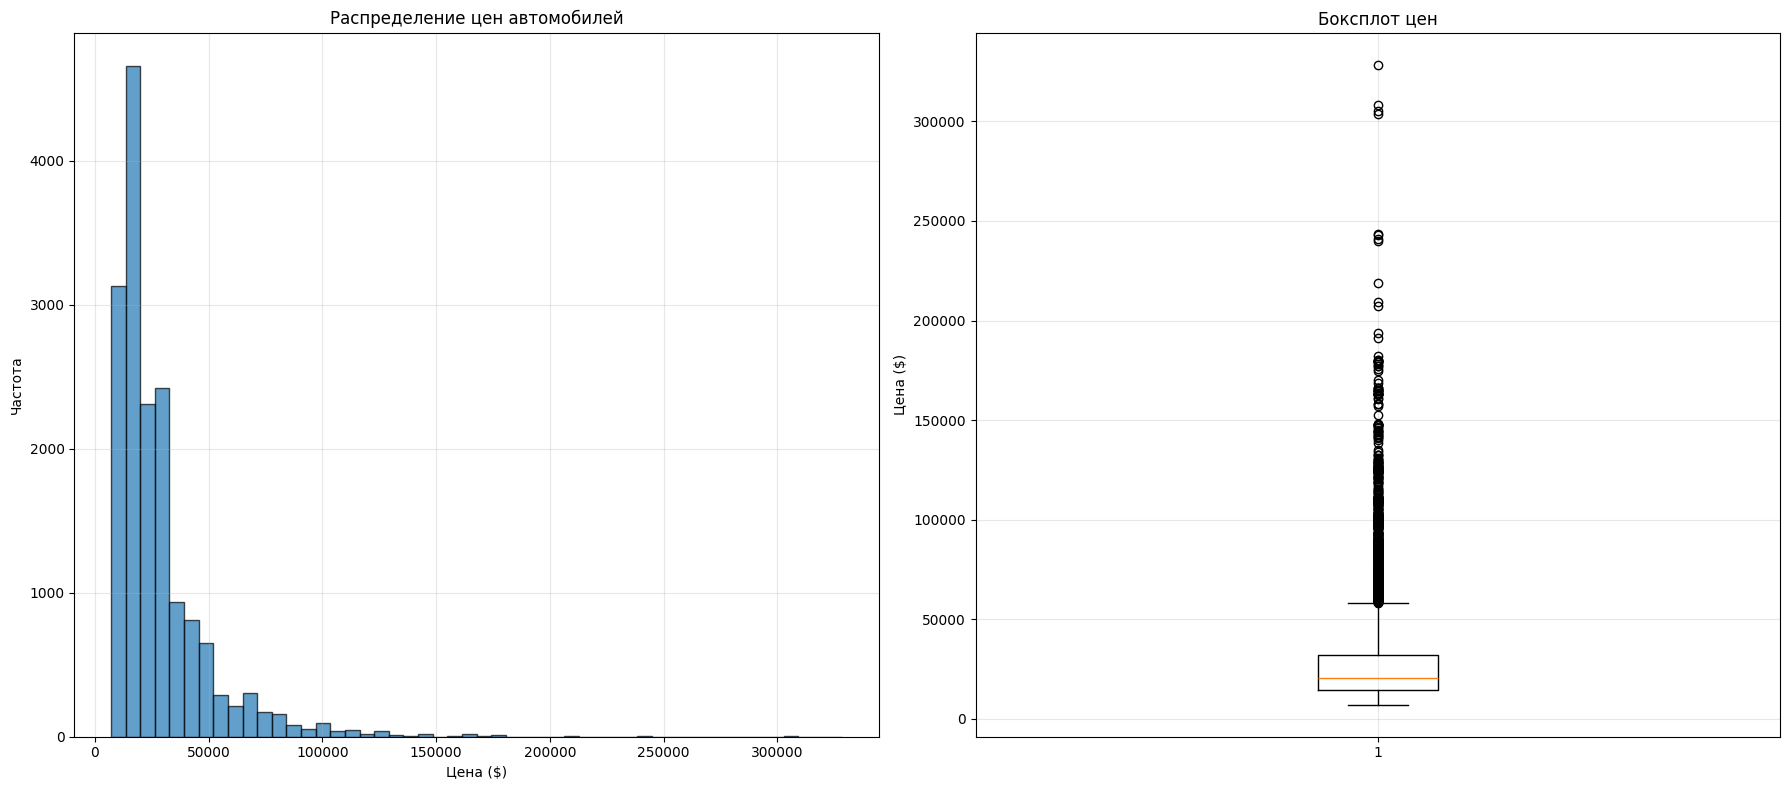

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].hist(df['price_usd'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цен автомобилей')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['price_usd'].dropna())
axes[1].set_ylabel('Цена ($)')
axes[1].set_title('Боксплот цен')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
df['price_usd'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,price_usd
count,16488.000000
mean,27892.720104
std,21701.745529
min,7100.000000
1%,7100.000000
5%,9884.695773
25%,14583.261233
50%,20700.000000
75%,32042.440320
95%,70610.079580


Распределение цен на автомобили в Казахстане имеет выраженную правостороннюю асимметрию, где основная масса автомобилей сосредоточена в среднебюджетном сегменте, а премиальные модели формируют длинный "хвост" распределения. Средняя цена составляет 27 893 долларов при медианной 20 700 долларов, причем разница в 7 193 долларов между этими показателями подтверждает значительное влияние дорогостоящих автомобилей на общую статистику. Высокое стандартное отклонение в 21 702 долларов свидетельствует о большой разнородности цен на рынке.

Анализ по квантилям выявляет четкую сегментацию рынка: бюджетный сегмент до 14 583 долларов (первые 25% рынка), средний сегмент 14 583–32 042 долларов (следующие 50% рынка), премиальный 32 042–70 610 долларов (20% рынка) и люксовый от 70 610 долларов (верхние 5% рынка). Основной объем продаж концентрируется в диапазоне 15 000–35 000 долларов, что делает этот сегмент ключевым для массовых продаж, тогда как премиальный сегмент, несмотря на меньший объем, обладает высоким потенциалом.

Максимальная цена 328 511 долларов значительно превышает 99-й перцентиль (110 500 долларов), демонстрируя наличие единичных сверхдорогих предложений, которые сильно искажают среднее значение. Практически три четверти всех автомобилей продаются по цене ниже 32 042 долларов, что подчеркивает доминирование среднебюджетного сегмента на казахстанском рынке.

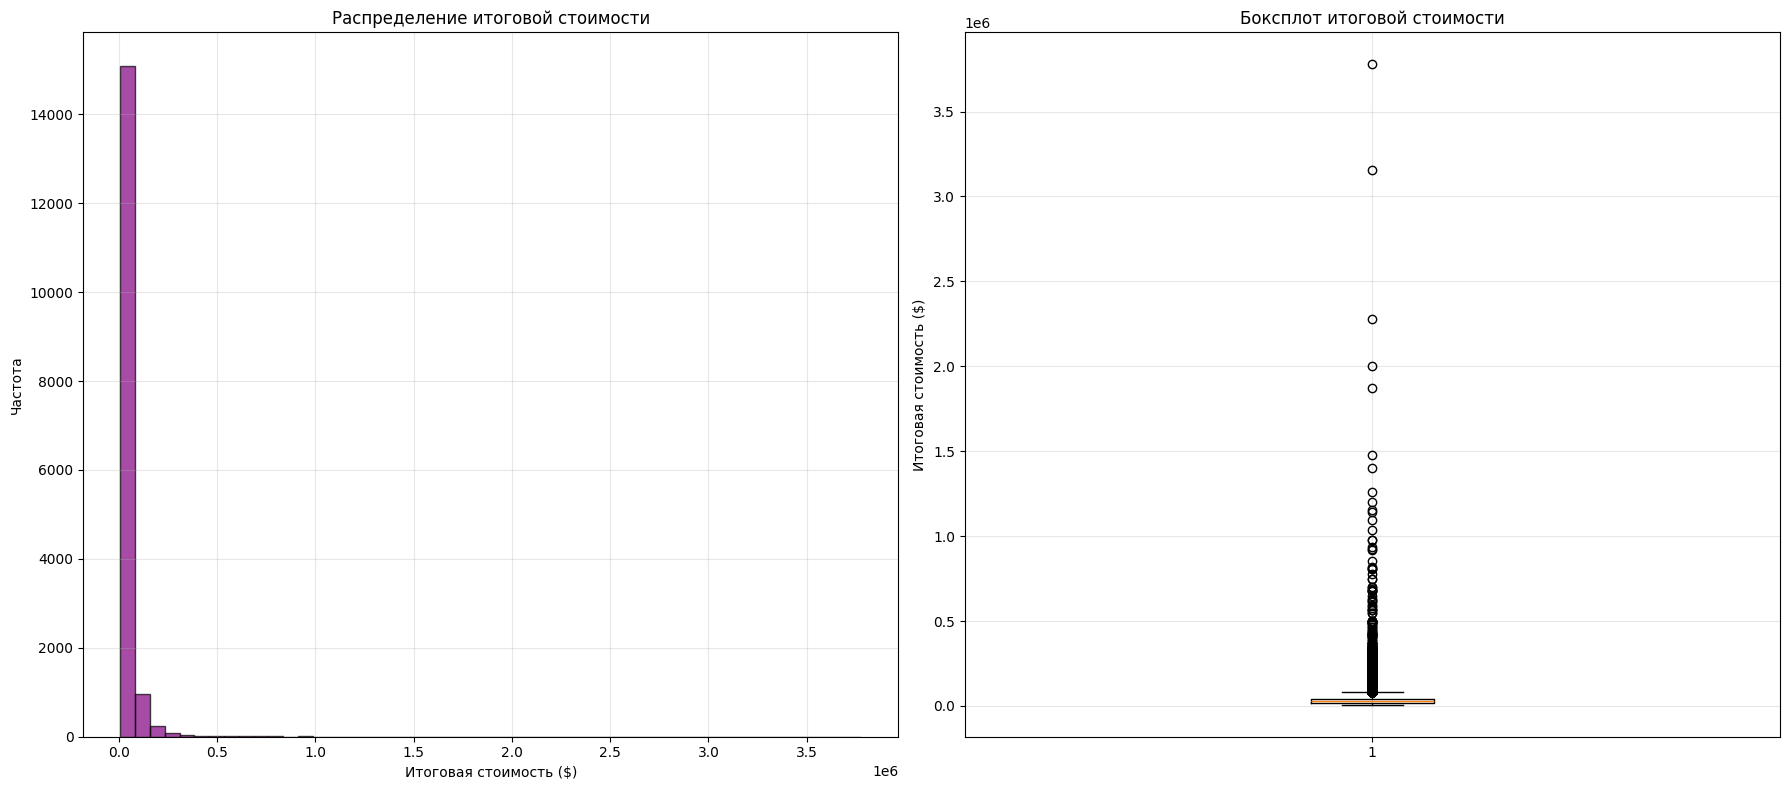

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].hist(df['sold_price_usd'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='purple')
axes[0].set_xlabel('Итоговая стоимость ($)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение итоговой стоимости')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['sold_price_usd'].dropna())
axes[1].set_ylabel('Итоговая стоимость ($)')
axes[1].set_title('Боксплот итоговой стоимости')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:

df['sold_price_usd'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,sold_price_usd
count,1.648800e+04
mean,4.109742e+04
std,7.477917e+04
min,7.100000e+03
1%,9.153785e+03
5%,1.160000e+04
25%,1.695569e+04
50%,2.624896e+04
75%,4.212917e+04
95%,1.083545e+05


Распределение итоговой стоимости продаж демонстрирует чрезвычайно резкую асимметрию с экстремальными выбросами, что хорошо видно на графике: основная масса данных сконцентрирована в начале координат, а отдельные точки растягиваются до 3,78 миллиона долларов. Средняя стоимость сделки составляет 41 097 долларов при медианной 26 249 долларов — разница в 14 848 долларов явно указывает на сильное влияние крупных оптовых продаж на общую статистику.

Стандартное отклонение в 74 779 долларов более чем в 1,8 раза превышает среднее значение, что подтверждает крайнюю неоднородность данных и присутствие выбросов значительной величины.

Анализ по квантилям показывает следующую структуру рынка:
- Бюджетный сегмент (25% сделок): до 16 956 долларов
- Средний сегмент (50% сделок): 16 956–42 129 долларов
- Премиальный сегмент (20% сделок): 42 129–108 355 долларов
- Люксовый/оптовый сегмент (5% сделок): от 108 355 долларов

Основная масса транзакций (50% рынка) действительно сосредоточена в диапазоне 17 000–42 000 долларов, тогда как 5% самых крупных сделок превышают 108 000 долларов, а 1% верхних сделок — свыше 261 000 долларов.

Наиболее значительная аномалия — максимальное значение в 3,78 миллиона долларов (3 778 206 долларов), которое почти в 15 раз превышает 99-й перцентиль (261 000 долларов) и свидетельствует о корпоративных закупках или крупных оптовых поставках.

Это означает необходимость раздельного анализа розничных и оптовых продаж, поскольку последние существенно искажают средние показатели. Основной бизнес-потенциал сосредоточен в сегменте 17 000–42 000 долларов, где сконцентрирована основная масса розничных клиентов.

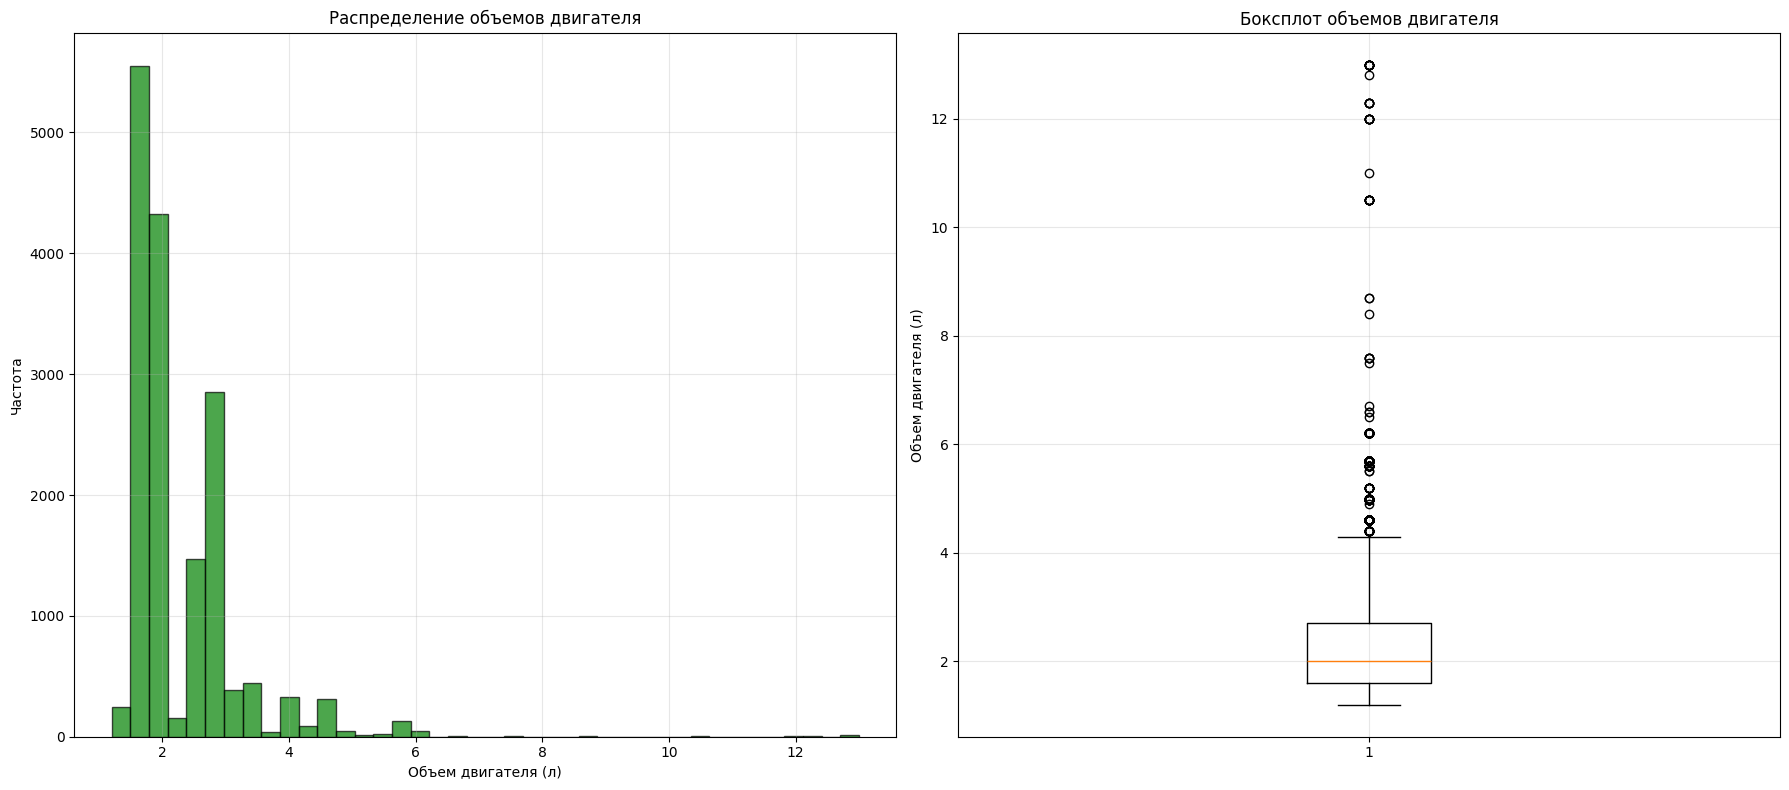

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].hist(df['engine_volume'].dropna(), bins=40, alpha=0.7, edgecolor='black', color='green')
axes[0].set_xlabel('Объем двигателя (л)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение объемов двигателя')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['engine_volume'].dropna())
axes[1].set_ylabel('Объем двигателя (л)')
axes[1].set_title('Боксплот объемов двигателя')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [92]:

df['engine_volume'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,engine_volume
count,16488.000000
mean,2.275172
std,0.923330
min,1.200000
1%,1.248000
5%,1.596000
25%,1.600000
50%,2.000000
75%,2.700000
95%,4.000000


Распределение объемов двигателя демонстрирует ярко выраженную мультимодальную структуру с четкими пиками популярности на конкретных значениях, что отражает предпочтения казахстанского рынка к определенным техническим характеристикам. Средний объем составляет 2,27 литра при медианном значении 2,0 литра — незначительная разница в 0,27 литра указывает на относительно сбалансированное распределение без выраженного влияния экстремальных значений.

Анализ по квантилям раскрывает четкую сегментацию рынка: первые 25% автомобилей имеют объем до 1,6 литра, следующие 50% сосредоточены в диапазоне 1,6–2,7 литра, следующие 20% — 2,7–4,0 литра, а верхние 5% превышают 4,0 литра. Основной рынок (50% всех продаж) действительно сконцентрирован в диапазоне 1,6–2,7 литра, с выраженными пиками на 1,6 литра, 2,0 литра и 2,5 литра — типичных значениях для массового сегмента, соответствующих популярным классам компактных и среднеразмерных автомобилей.

95% процентов автомобилей имеют объем до 4,0 литра, что четко определяет границу массового рынка. Особого внимания заслуживают экстремальные значения, достигающие 13,0 литров, которые, вероятно, относятся к спецтехнике, коммерческим транспортным средствам или эксклюзивным автомобилям высшего класса.

Интересно отметить, что 25-й перцентиль (1,6 литра) совпадает с одним из самых популярных значений на рынке, что говорит о существовании значительного сегмента экономичных автомобилей. При этом 75-й перцентиль (2,7 литра) также соответствует популярному объему. Оптимальной рыночной стратегией является фокус на двигателях объемом 1,6–2,7 литра, где сконцентрирован основной потребительский спрос.

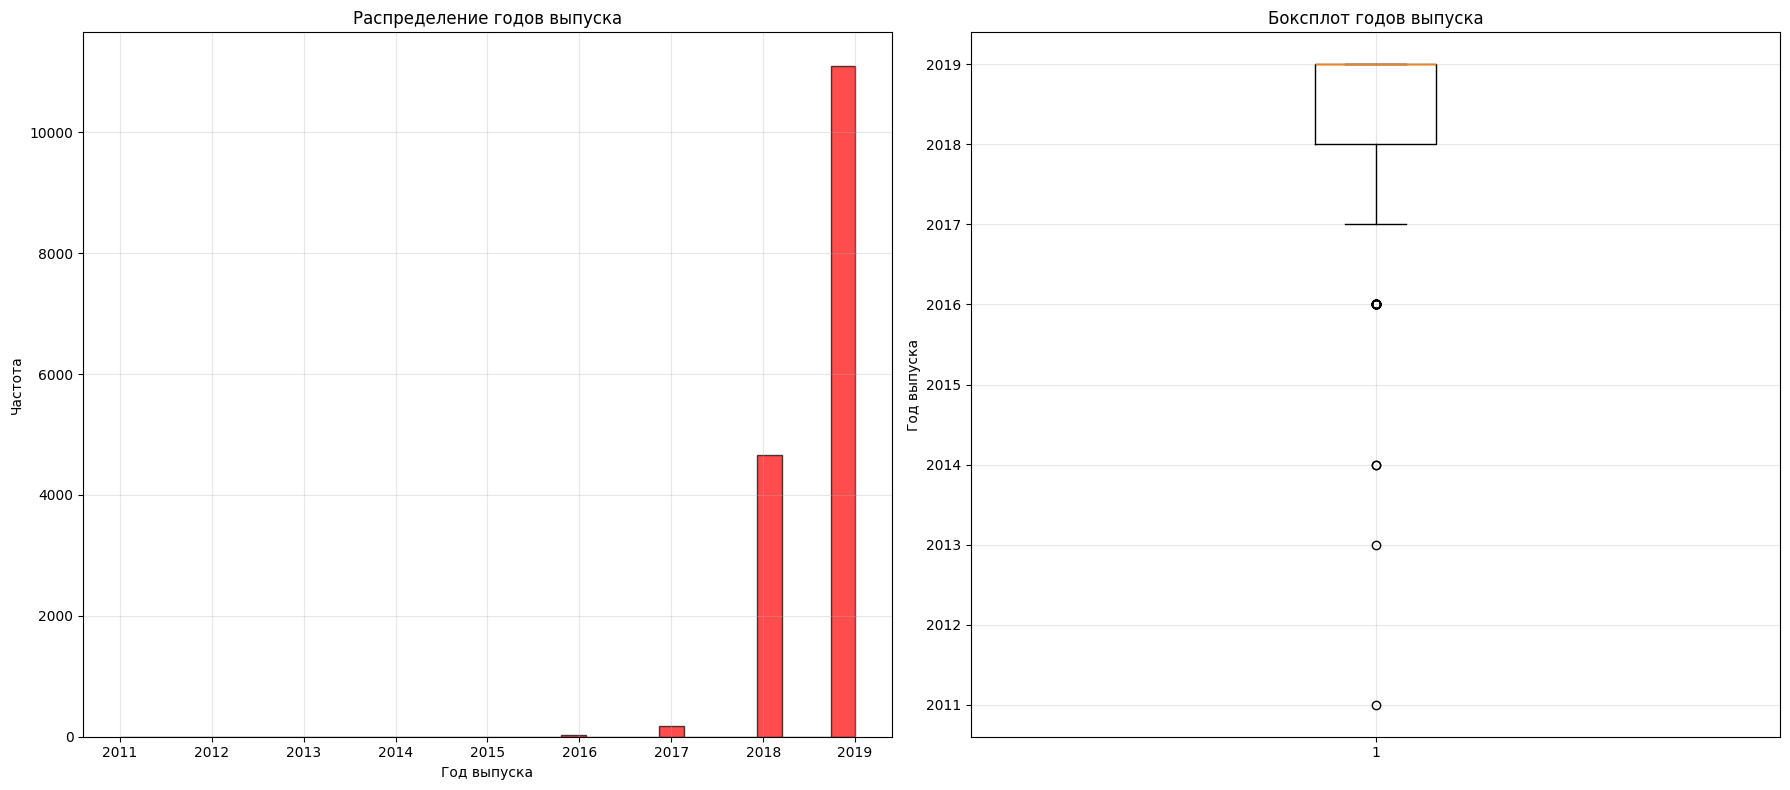

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].hist(df['manufacture_year'].dropna(), bins=30, alpha=0.7, edgecolor='black', color='red')
axes[0].set_xlabel('Год выпуска')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение годов выпуска')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['manufacture_year'].dropna())
axes[1].set_ylabel('Год выпуска')
axes[1].set_title('Боксплот годов выпуска')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [94]:

df['manufacture_year'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,manufacture_year
count,15971.0
mean,2018.679043
std,0.508338
min,2011.0
1%,2017.0
5%,2018.0
25%,2018.0
50%,2019.0
75%,2019.0
95%,2019.0


Распределение годов выпуска демонстрирует экстремальную концентрацию на новых автомобилях с однородностью рынка. Рынок практически полностью состоит из автомобилей 2018-2019 годов выпуска, причем 75% всех проданных автомобилей были произведены в 2019 году. Средний год выпуска составляет 2018,68 при медианном 2019 году, что подтверждает абсолютное доминирование самых свежих моделей.

Крайне низкое стандартное отклонение в 0,51 года указывает на минимальный разброс данных — практически все автомобили сконцентрированы на временном отрезке менее одного года. Анализ по квантилям показывает следующее распределение: 1% самых старых автомобилей — 2017 года и ранее, 5% — 2018 года и ранее, тогда как 25-й перцентиль уже соответствует 2018 году, а все остальные квантили (50%, 75%, 95%, 99%) — исключительно 2019 году.

Автомобили старше 2017 года составляют менее 1% рынка, что свидетельствует о практически отсутствующей доле подержанных автомобилей в общем объеме продаж. Это означает работу практически исключительно на рынке новых автомобилей, где ключевыми являются актуальные модели последних лет выпуска. Наличие минимального значения в 2011 году является единичной аномалией.

### Изучим продажи по брендам, моделям, регионам, типам топлива и коробкам передач.

Для начала построим для брендов, моделей, регионов, типов топлива и коробок передач столбчатые диаграммы. Что узнать и сравнить количество продаж по каждому столбцу и их выручку (по итоговой стоимости).

Затем статистику: сколько продаж, выручка, средняя цена и доля на рынке.

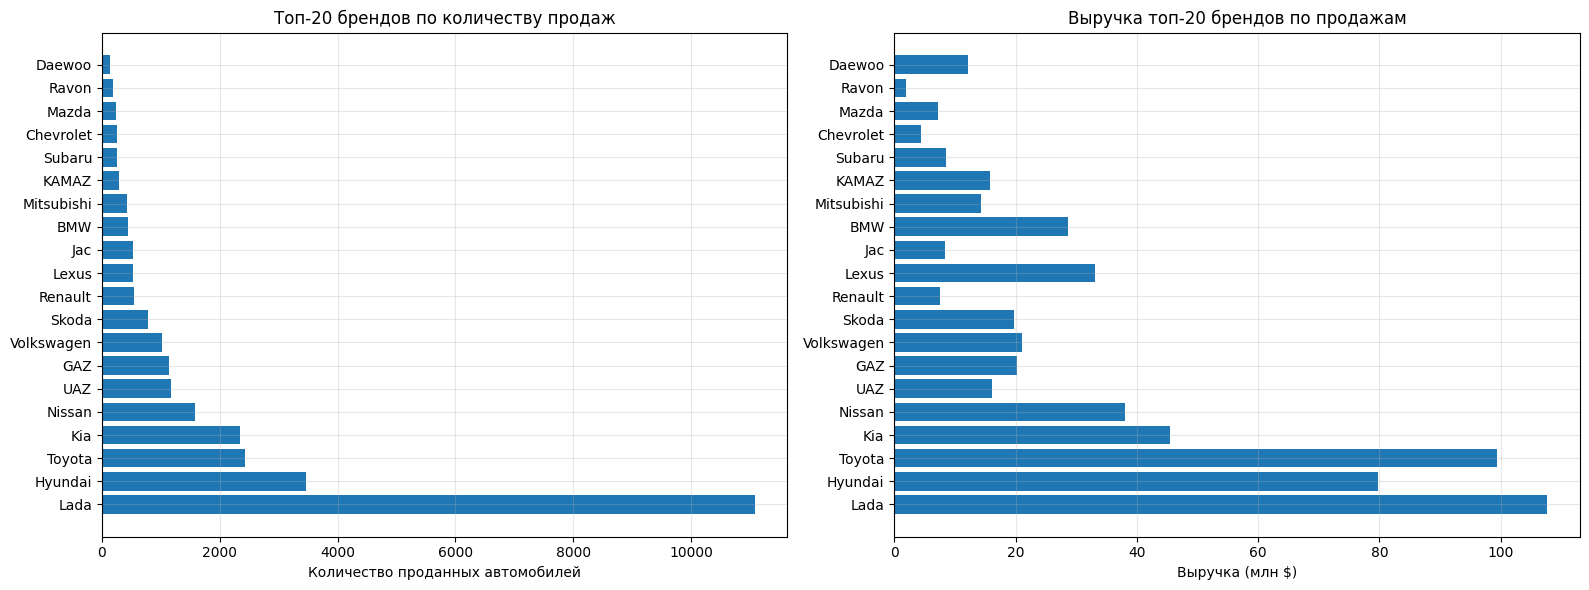

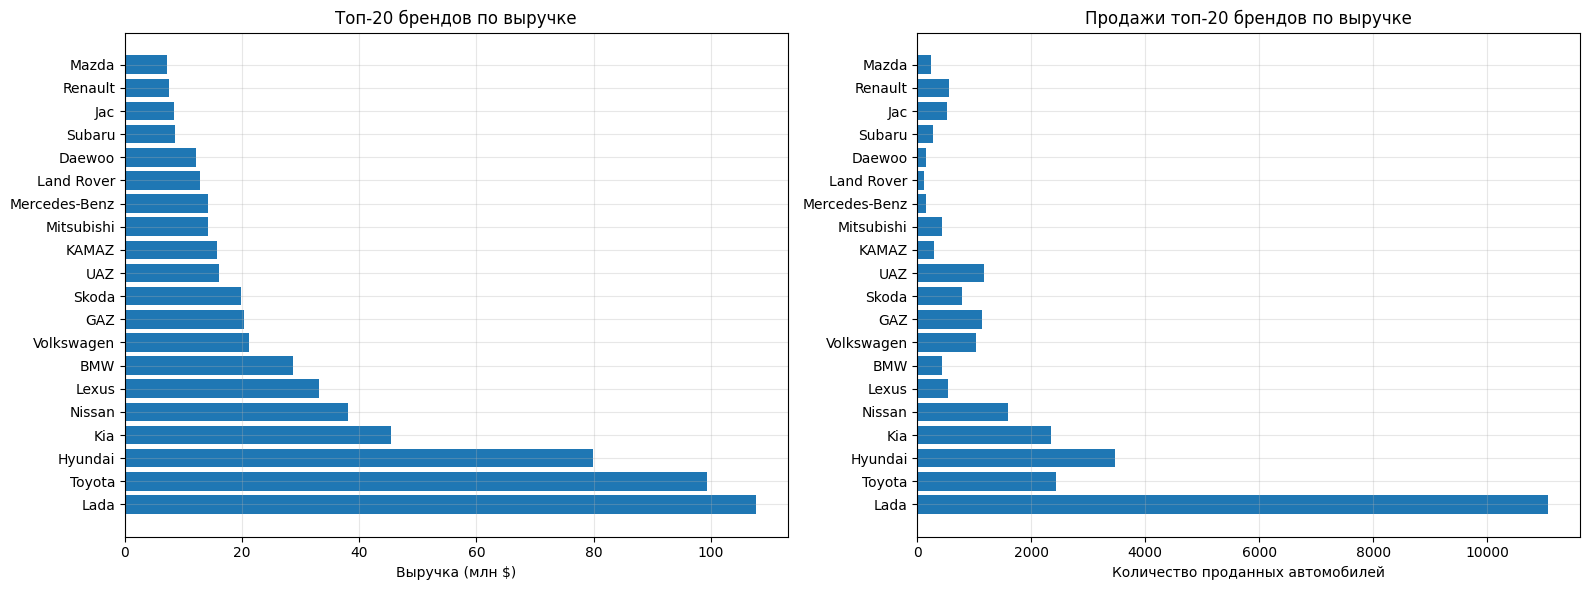

In [95]:
brand_sales = df.groupby('brand').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('quantity', ascending=False)
top_brand = brand_sales.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_brand.index, top_brand['quantity'])
axes[0].set_xlabel('Количество проданных автомобилей')
axes[0].set_title('Топ-20 брендов по количеству продаж')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_brand.index, top_brand['sold_price_usd'] / 1e6)
axes[1].set_xlabel('Выручка (млн $)')
axes[1].set_title('Выручка топ-20 брендов по продажам')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

brand_sales_price = df.groupby('brand').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('sold_price_usd', ascending=False)
top_brand_price = brand_sales_price.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_brand_price.index, top_brand_price['sold_price_usd'] / 1e6)
axes[0].set_xlabel('Выручка (млн $)')
axes[0].set_title('Топ-20 брендов по выручке')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_brand_price.index, top_brand_price['quantity'])
axes[1].set_xlabel('Количество проданных автомобилей')
axes[1].set_title('Продажи топ-20 брендов по выручке')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:

print("Статистика по брендам (Топ-20 по продажам):\n")
print(f"{'Бренд':<15}   {'Количество':<12}   {'Выручка':<12}   {'Средняя':<10}   {'Доля':<12}")
print(f"{'':<15}   {'авто':<12}   {'(млн $)':<12}   {'цена ($)':<10}   {'рынка (%)':<12}")
total_cars_brands = brand_sales['quantity'].sum()
for brand in top_brand.index:
    data = top_brand.loc[brand]
    market_share = (data['quantity'] / total_cars_brands * 100)
    print(f"{brand:<15}   {int(data['quantity']):>11}    {data['sold_price_usd']/1e6:>10.1f}    {data['price_usd']:>8.0f}   {market_share:>10.2f}%")


Статистика по брендам (Топ-20 по продажам):

Бренд             Количество     Выручка        Средняя      Доля        
                  авто           (млн $)        цена ($)     рынка (%)   
Lada                    11079         107.7       10699        36.52%
Hyundai                  3471          79.8       22999        11.44%
Toyota                   2424          99.4       41013         7.99%
Kia                      2346          45.4       21173         7.73%
Nissan                   1588          38.0       24641         5.23%
UAZ                      1166          16.1       14278         3.84%
GAZ                      1139          20.2       17767         3.75%
Volkswagen               1024          21.1       23656         3.38%
Skoda                     777          19.7       26218         2.56%
Renault                   549           7.5       13572         1.81%
Lexus                     528          33.1       62745         1.74%
Jac                       525        

Исследование продаж по автомобильным брендам выявляет структуру казахстанского рынка: количественное доминирование отечественного производителя.

Lada демонстрирует абсолютное лидерство по объему продаж - 11 079 автомобилей (36,52% рынка), что составляет более трети всех проданных автомобилей. Бренд генерирует выручку в 107,7 млн долларов при средней цене 10 699 долларов, что подтверждает его позицию как основного поставщика автомобилей для массового рынка.

Однако по эффективности продаж выделяются другие бренды: Toyota при меньшем объеме (2 424 автомобиля, 7,99% рынка) генерирует сравнимую выручку — 99,4 млн долларов — благодаря значительно более высокой средней цене в 41 013 долларов.

Среди специальных брендов выделяются KAMAZ (297 автомобилей, средняя цена 52 944 доллара) и Daewoo (146 автомобилей, средняя цена 90 717 долларов), чьи высокие средние цены, вероятно, связаны с продажей коммерческой и специальной техники.

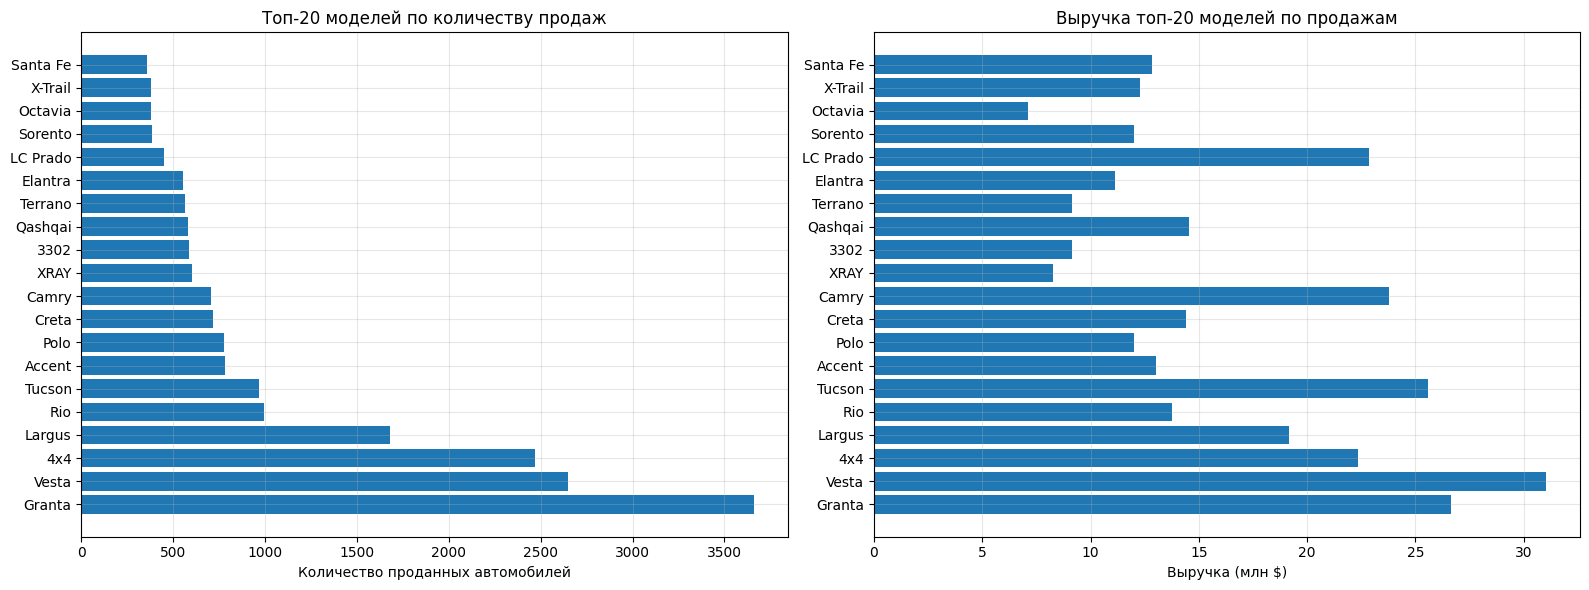

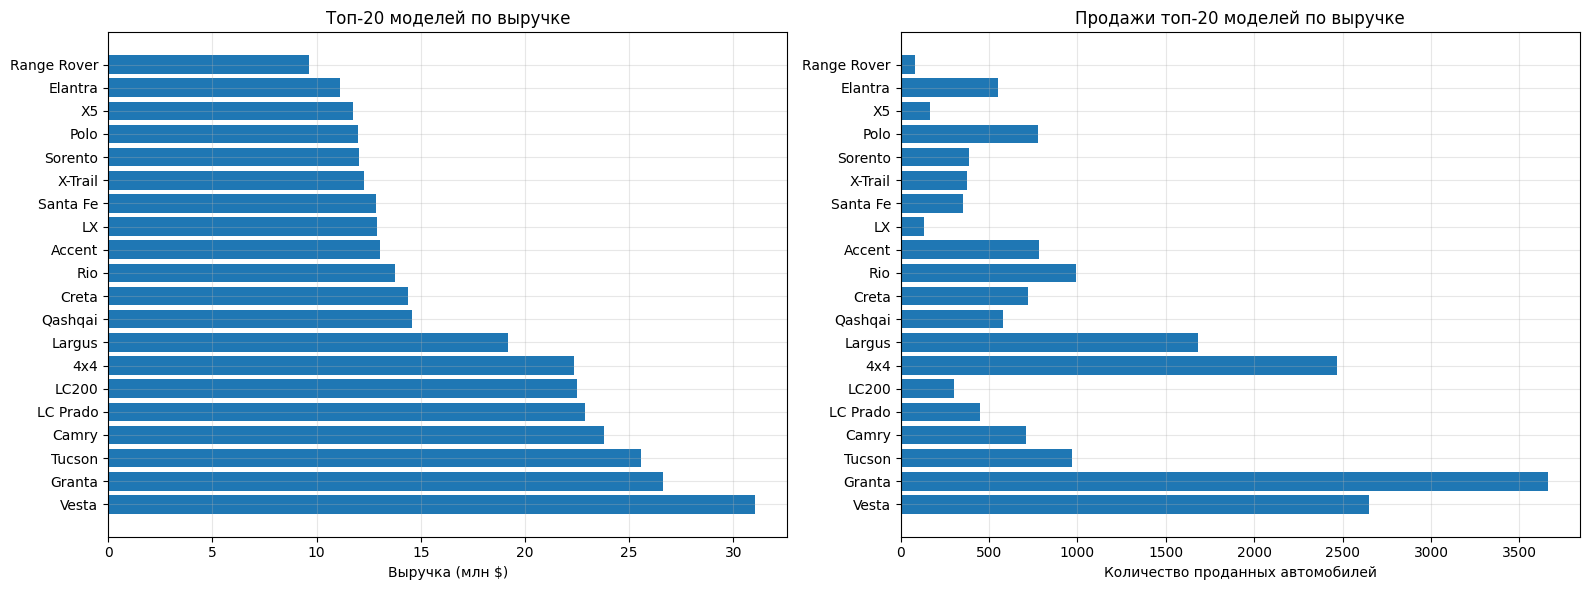

In [97]:
model_sales = df.groupby('model').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('quantity', ascending=False)
top_model = model_sales.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_model.index, top_model['quantity'])
axes[0].set_xlabel('Количество проданных автомобилей')
axes[0].set_title('Топ-20 моделей по количеству продаж')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_model.index, top_model['sold_price_usd'] / 1e6)
axes[1].set_xlabel('Выручка (млн $)')
axes[1].set_title('Выручка топ-20 моделей по продажам')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

model_sales_price = df.groupby('model').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('sold_price_usd', ascending=False)
top_model_price = model_sales_price.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_model_price.index, top_model_price['sold_price_usd'] / 1e6)
axes[0].set_xlabel('Выручка (млн $)')
axes[0].set_title('Топ-20 моделей по выручке')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_model_price.index, top_model_price['quantity'])
axes[1].set_xlabel('Количество проданных автомобилей')
axes[1].set_title('Продажи топ-20 моделей по выручке')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
print("\nСтатистика по моделям (Топ-20 по продажам):")
print(f"\n{'Модель':<20}   {'Количество':<12}   {'Выручка':<12}   {'Средняя':<10}   {'Доля':<12}")
print(f"{'':<20}   {'авто':<12}   {'(млн $)':<12}   {'цена ($)':<10}   {'рынка (%)':<12}")
total_cars_models = model_sales['quantity'].sum()
for model in top_model.index:
    data = top_model.loc[model]
    market_share = (data['quantity'] / total_cars_models * 100)
    print(f"{model:<20}   {int(data['quantity']):>11}   {data['sold_price_usd']/1e6:>10.1f}   {data['price_usd']:>8.0f}   {market_share:>10.2f}")



Статистика по моделям (Топ-20 по продажам):

Модель                 Количество     Выручка        Средняя      Доля        
                       авто           (млн $)        цена ($)     рынка (%)   
Granta                        3660         26.6       7355        12.06
Vesta                         2647         31.0      11772         8.73
4x4                           2469         22.3       9076         8.14
Largus                        1682         19.2      11452         5.54
Rio                            993         13.8      13995         3.27
Tucson                         967         25.6      26455         3.19
Accent                         781         13.0      16678         2.57
Polo                           774         12.0      14876         2.55
Creta                          718         14.4      20050         2.37
Camry                          707         23.8      33651         2.33
XRAY                           600          8.2      13735         1.98
3302

Исследование продаж автомобилей по моделям выявляет двойственную структуру казахстанского рынка: с одной стороны, абсолютное количественное доминирование бюджетных моделей Lada, с другой — значительный вклад в выручку со стороны более дорогих автомобилей, особенно премиального сегмента.

Модели Lada доминируют по объемам продаж: Granta (3 660 авто, 12,06% рынка), Vesta (2 647 авто, 8,73%) и 4x4 (2 469 авто, 8,14%) суммарно занимают 28,93% рынка.

Однако по выручке картина иная: Vesta при меньшем объеме, чем Granta, генерирует большую выручку (31,0 млн долларов против 26,6 млн долларов) за счет более высокой средней цены (11 772 доллара против 7 355 долларов). Largus также демонстрирует аналогичный эффект с выручкой 19,2 млн долларов при объеме 1 682 автомобиля.

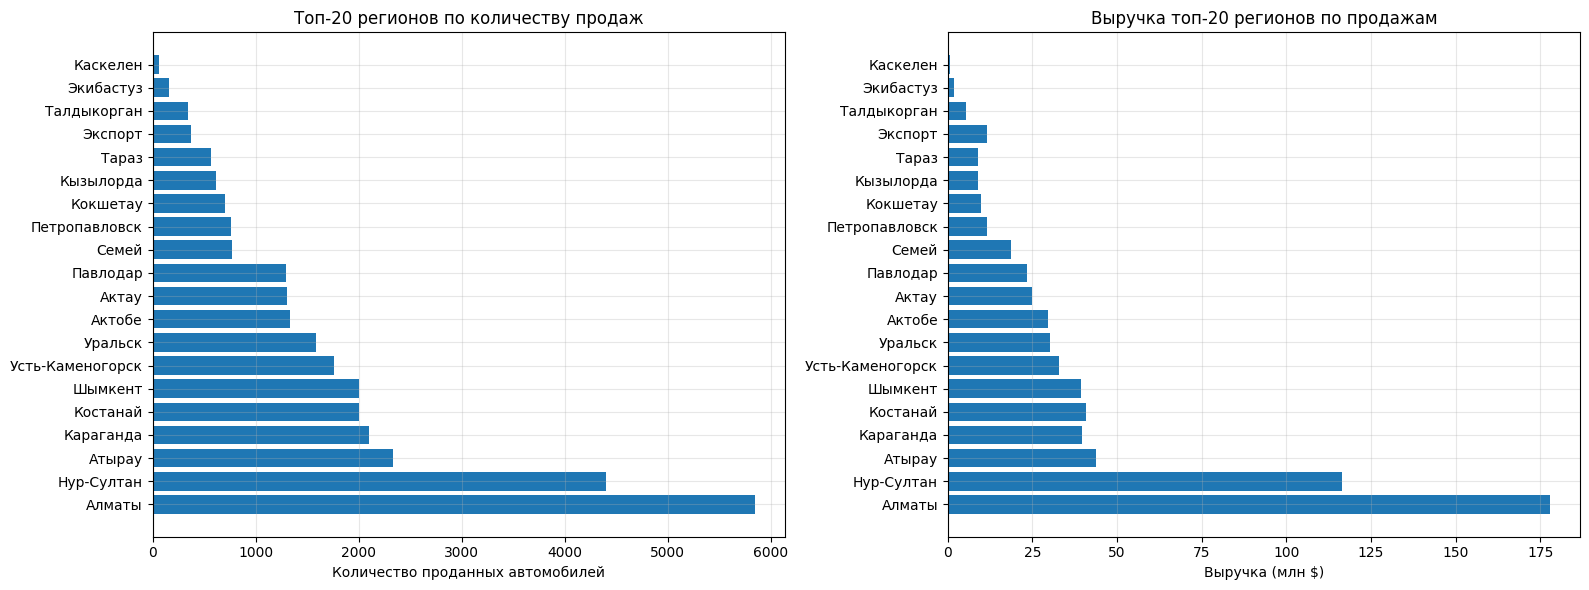

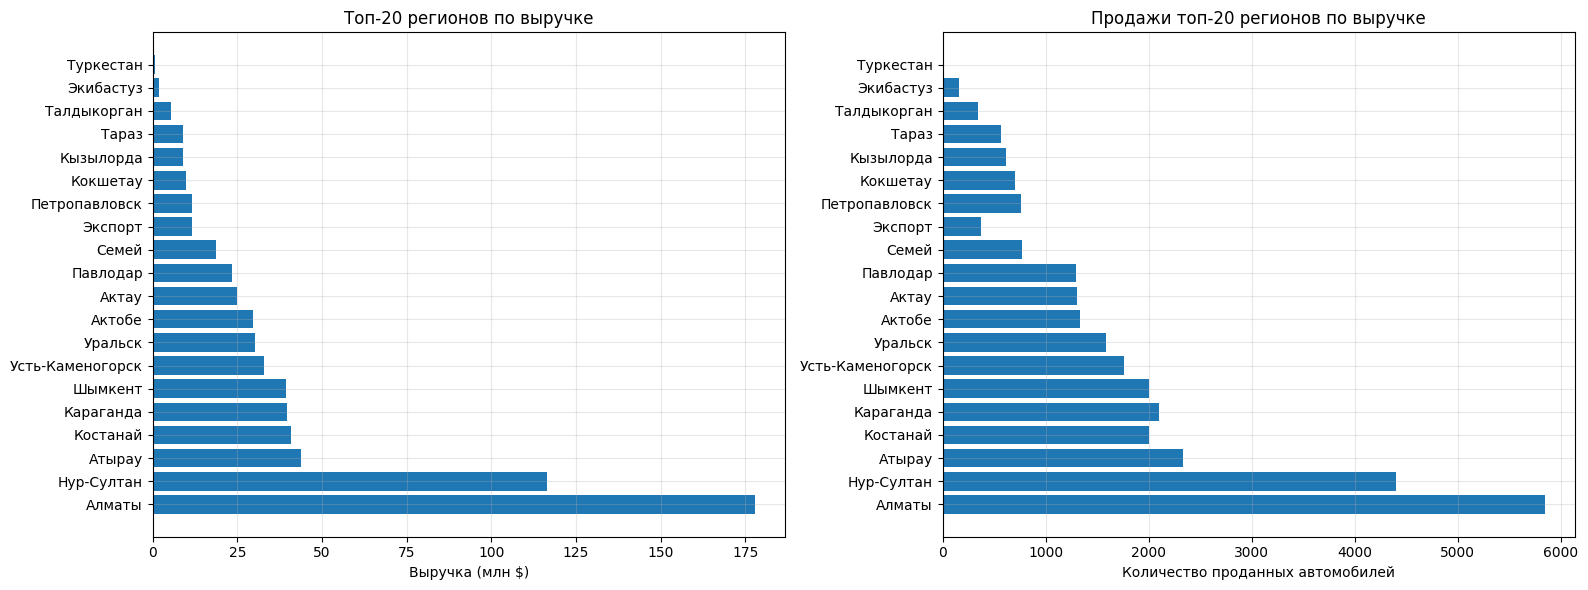

In [99]:
region_sales = df.groupby('region').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('quantity', ascending=False)
top_region = region_sales.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_region.index, top_region['quantity'])
axes[0].set_xlabel('Количество проданных автомобилей')
axes[0].set_title('Топ-20 регионов по количеству продаж')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_region.index, top_region['sold_price_usd'] / 1e6)
axes[1].set_xlabel('Выручка (млн $)')
axes[1].set_title('Выручка топ-20 регионов по продажам')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

region_sales_price = df.groupby('region').agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('sold_price_usd', ascending=False)
top_region_price = region_sales_price.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_region_price.index, top_region_price['sold_price_usd'] / 1e6)
axes[0].set_xlabel('Выручка (млн $)')
axes[0].set_title('Топ-20 регионов по выручке')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_region_price.index, top_region_price['quantity'])
axes[1].set_xlabel('Количество проданных автомобилей')
axes[1].set_title('Продажи топ-20 регионов по выручке')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [100]:
print("\n\nСтатистика по регионам (Топ-20 по продажам):\n")
print(f"{'Регион':<20}   {'Количество':<12}   {'Выручка':<12}   {'Средняя':<10}   {'Доля':<12}")
print(f"{'':<20}   {'авто':<12}   {'(млн $)':<12}   {'цена ($)':<10}   {'рынка (%)':<12}")
total_cars_regions = region_sales['quantity'].sum()
for region in top_region.index:
    data = top_region.loc[region]
    market_share = (data['quantity'] / total_cars_regions * 100)
    print(f"{region:<20}   {int(data['quantity']):>11}    {data['sold_price_usd']/1e6:>10.1f}    {data['price_usd']:>8.0f}   {market_share:>10.2f}%")



Статистика по регионам (Топ-20 по продажам):

Регион                 Количество     Выручка        Средняя      Доля        
                       авто           (млн $)        цена ($)     рынка (%)   
Алматы                        5844         177.9       37685        19.26%
Нур-Султан                    4399         116.6       31841        14.50%
Атырау                        2334          43.8       25055         7.69%
Караганда                     2095          39.8       23533         6.91%
Костанай                      2005          41.0       26131         6.61%
Шымкент                       2002          39.4       26173         6.60%
Усть-Каменогорск              1759          32.9       24949         5.80%
Уральск                       1587          30.3       24588         5.23%
Актобе                        1336          29.7       27882         4.40%
Актау                         1300          24.9       25317         4.29%
Павлодар                      1290          

Исследование регионального распределения продаж автомобилей в Казахстане выявляет выраженную географическую концентрацию рынка вокруг крупнейших городов. Два мегаполиса — Алматы и Нур-Султан — доминируют в продажах: на них приходится 33,76% всех проданных автомобилей и 43,37% общей выручки.

Алматы является безусловным лидером рынка с 5 844 проданными автомобилями (19,26% от общего объема), выручкой 177,9 млн долларов и самой высокой среди регионов средней ценой в 37 685 долларов. Это свидетельствует о концентрации в городе как премиального сегмента, так и массовых продаж.

Нур-Султан занимает второе место с 4 399 проданными автомобилями (14,50% рынка) и выручкой 116,6 млн долларов при средней цене 31 841 доллар, что также указывает на развитый рынок с преобладанием среднеценового сегмента.

Далее следуют промышленные и нефтегазовые регионы: Атырау (7,69% рынка), Караганда (6,91%), Костанай (6,61%) и Шымкент (6,60%). Эти регионы демонстрируют значительные объемы продаж от 2 000 до 2 334 автомобилей с выручкой от 39,4 до 43,8 млн долларов.

Отдельного внимания заслуживает категория "Экспорт", которая показывает наивысшую среднюю цену после Алматы — 37 049 долларов при относительно небольшом объеме в 373 автомобиля (1,23% рынка). Это указывает на то, что на экспорт отправляются преимущественно дорогие модели.

Визуализация наглядно показывает резкий разрыв между лидирующими регионами и остальными: первые два города (Алматы и Нур-Султан) суммарно продают больше автомобилей, чем следующие восемь регионов вместе взятых. Такая концентрация отражает урбанизированную структуру автомобильного рынка Казахстана, где крупные города являются основными драйверами продаж как массового, так и премиального сегментов.

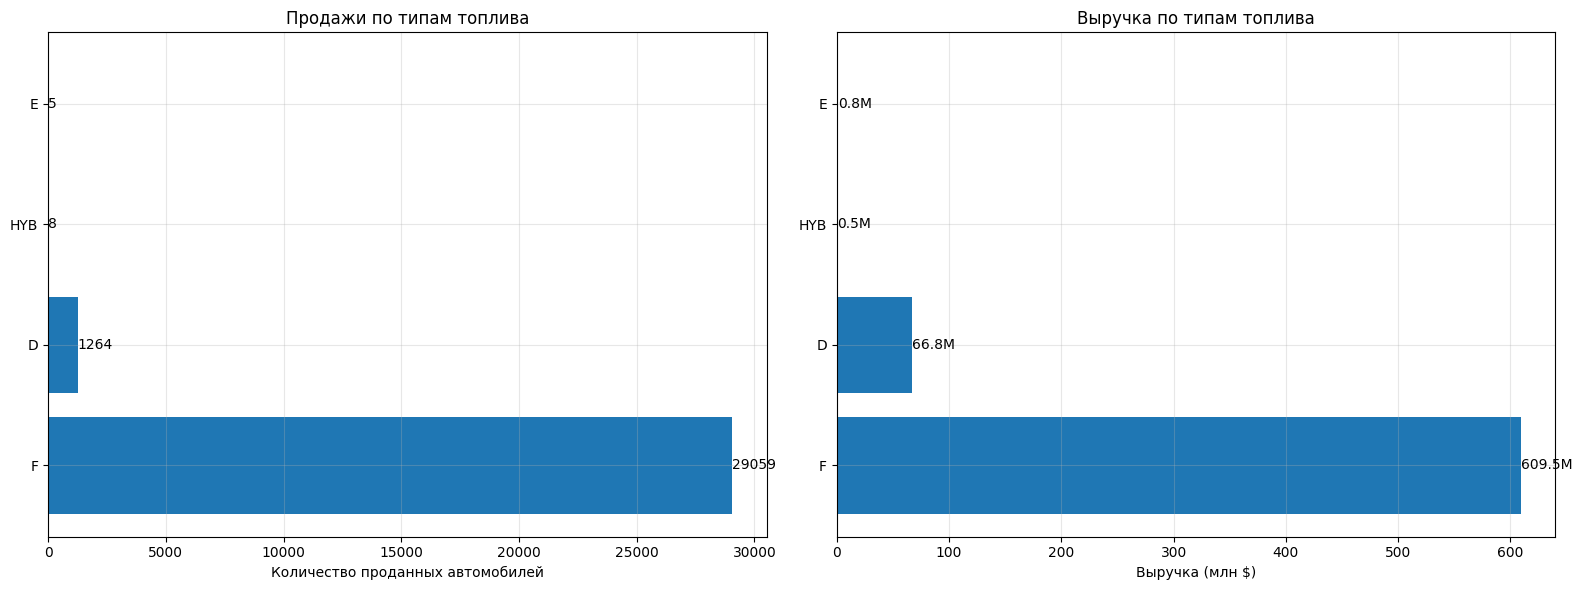

In [101]:
fuel_sales = df.groupby('fuel_type', observed=False).agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('quantity', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(fuel_sales.index, fuel_sales['quantity'])
axes[0].set_xlabel('Количество проданных автомобилей')
axes[0].set_title('Продажи по типам топлива')
axes[0].grid(True, alpha=0.3)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(width, bar.get_y() + bar.get_height()/2,
                f'{int(width)}',
                ha='left', va='center', fontsize=10)

bars2 = axes[1].barh(fuel_sales.index, fuel_sales['sold_price_usd'] / 1e6)
axes[1].set_xlabel('Выручка (млн $)')
axes[1].set_title('Выручка по типам топлива')
axes[1].grid(True, alpha=0.3)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}M',
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [102]:
print("Статистика по типам топлива:\n")
print(f"{'Тип':<4}   {'Количество':<12}   {'Выручка':<12}   {'Средняя':<10}   {'Доля':<12}")
print(f"{'':<4}   {'авто':<12}   {'(млн $)':<12}   {'цена ($)':<10}   {'рынка (%)':<12}")

for fuel_type in fuel_sales.index:
    data = fuel_sales.loc[fuel_type]
    market_share = (data['quantity'] / fuel_sales['quantity'].sum() * 100)
    print(f"{fuel_type:>4}   {int(data['quantity']):>11}    {data['sold_price_usd']/1e6:>10.1f}    {data['price_usd']:>8.0f}   {market_share:>10.4f}")

Статистика по типам топлива:

Тип    Количество     Выручка        Средняя      Доля        
       авто           (млн $)        цена ($)     рынка (%)   
   F         29059         609.5       26855      95.7905
   D          1264          66.8       49007       4.1667
 HYB             8           0.5       67574       0.0264
   E             5           0.8      153974       0.0165


Анализ продаж по типам топлива показывает абсолютное доминирование бензиновых автомобилей на казахстанском рынке: за анализируемый период было продано 29 059 автомобилей на бензине (95,79% рынка) с общей выручкой 609,5 млн долларов. Это составляет подавляющее большинство как по количеству продаж, так и по выручке.

Дизельные автомобили занимают значительно меньшую долю: 1 264 проданных авто (4,17% рынка) с выручкой 66,8 млн долларов. Примечательно, что средняя цена дизельных автомобилей составляет 49 007 долларов — почти в два раза выше средней цены бензиновых моделей (26 855 долларов). Это указывает на то, что дизельные двигатели преобладают в более дорогих сегментах, вероятно, среди внедорожников, кроссоверов и коммерческих автомобилей.

Альтернативные виды топлива представлены крайне ограниченно: гибридные автомобили (8 проданных единиц, 0,026% рынка) с выручкой 0,5 млн долларов и электромобили (5 проданных единиц, 0,016% рынка) с выручкой 0,8 млн долларов демонстрируют рекордные средние цены — 67 574 и 153 974 долларов.

Таким образом, казахстанский автомобильный рынок остается традиционным с точки зрения видов топлива: бензиновые двигатели занимают доминирующее положение в массовом сегменте, дизельные — в более дорогих нишах, тогда как гибридные и электрические технологии представлены единичными продажами.

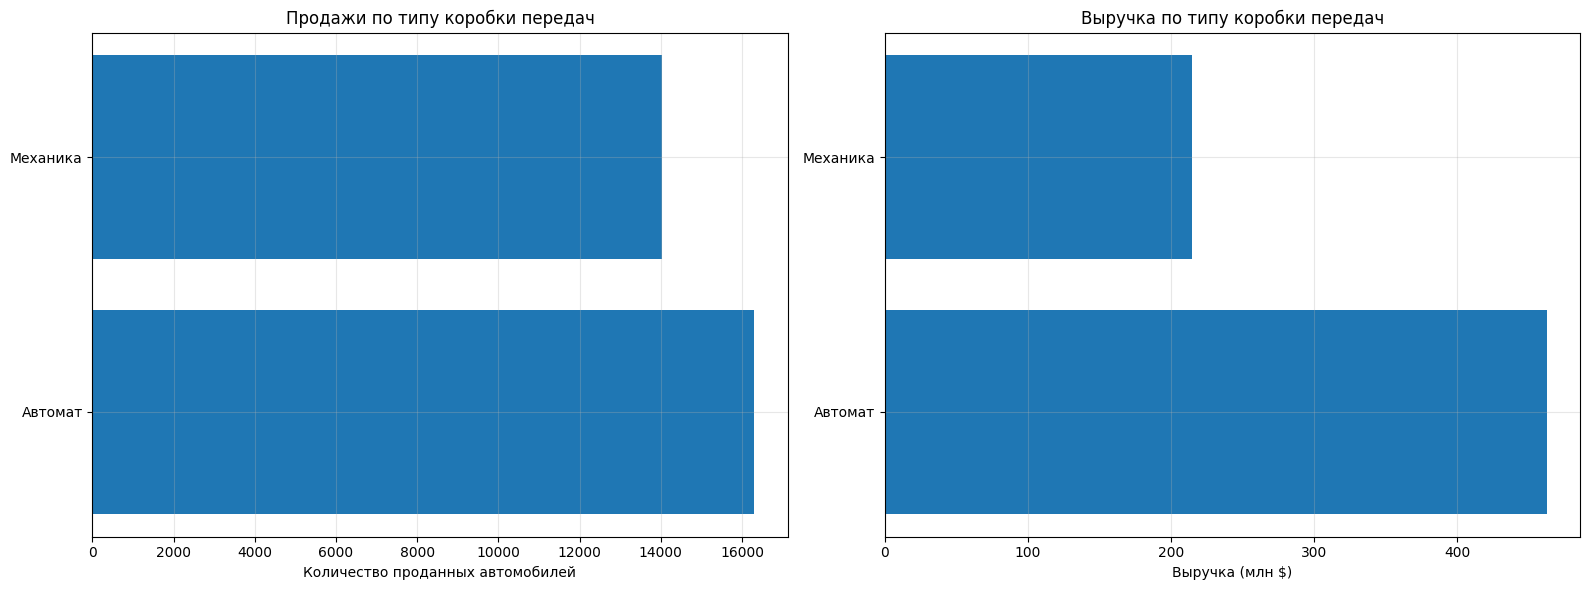

In [103]:
transmission_sales = df.groupby('transmission', observed=False).agg({
    'quantity': 'sum',
    'sold_price_usd': 'sum',
    'price_usd': 'mean'
}).round(2).sort_values('quantity', ascending=False)
top_transmission = transmission_sales.head(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_transmission.index, top_transmission['quantity'])
axes[0].set_xlabel('Количество проданных автомобилей')
axes[0].set_title('Продажи по типу коробки передач')
axes[0].grid(True, alpha=0.3)

axes[1].barh(top_transmission.index, top_transmission['sold_price_usd'] / 1e6)
axes[1].set_xlabel('Выручка (млн $)')
axes[1].set_title('Выручка по типу коробки передач')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [104]:
print("Статистика по типу коробки передач:\n")
print(f"{'Тип':<8}   {'Количество':<12}   {'Выручка':<12}   {'Средняя':<10}   {'Доля':<12}")
print(f"{'':<8}   {'авто':<12}   {'(млн $)':<12}   {'цена ($)':<10}   {'рынка (%)':<12}")
for transmission in transmission_sales.index:
    data = transmission_sales.loc[transmission]
    market_share = (data['quantity'] / transmission_sales['quantity'].sum() * 100)
    print(f"{transmission:<8}   {int(data['quantity']):>11}    {data['sold_price_usd']/1e6:>10.1f}    {data['price_usd']:>8.0f}   {market_share:>10.4f}")

Статистика по типу коробки передач:

Тип        Количество     Выручка        Средняя      Доля        
           авто           (млн $)        цена ($)     рынка (%)   
Автомат          16307         462.8       31609      53.7546
Механика         14029         214.8       19314      46.2454


Анализ продаж по типам коробок передач показывает умеренное преобладание автоматических трансмиссий в количественном выражении: за анализируемый период было продано 16 307 автомобилей с АКПП (53,75% рынка) против 14 029 автомобилей с МКПП (46,25% рынка). Несмотря на относительно близкие объемы продаж (разница составляет всего 2 278 автомобилей или 7,5% рынка), наблюдается существенный разрыв в их стоимостной структуре.

Ключевой инсайт заключается в ценовом позиционировании: средняя цена автомобиля с автоматической коробкой составляет 31 609 долларов, что на 12 295 долларов выше средней цены автомобиля с механической коробкой (19 314 долларов). Это ценовое различие определяет значительный дисбаланс в выручке: автомобили с АКПП генерируют 462,8 млн долларов (68,3% общей выручки), тогда как автомобили с МКПП — только 214,8 млн долларов (31,7%).

Таким образом, хотя автоматические трансмиссии лишь незначительно лидируют по количеству проданных единиц, они доминируют по вкладу в выручку, что указывает на их концентрацию в более дорогих рыночных сегментах.

### Выявим основные тренды и аномалии

Для выявления и анализа аномалий в данных мы будем использовать метод межквартильного размаха (IQR): цена, итоговая стоимость, объем двигателя, год производства, количество.

In [105]:
def analyze_outliers_iqr(data, column, column_name):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    lower_outliers = data[data[column] < lower_bound]
    upper_outliers = data[data[column] > upper_bound]

    return {
        'column': column_name,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'total_outliers': len(outliers),
        'lower_outliers': len(lower_outliers),
        'upper_outliers': len(upper_outliers),
        'outliers_percentage': len(outliers) / len(data) * 100,
        'min_value': data[column].min(),
        'max_value': data[column].max(),
        'outliers_data': outliers
    }

columns_to_analyze = [
    ('price_usd', 'Цена автомобиля ($)'),
    ('sold_price_usd', 'Итоговая стоимость ($)'),
    ('engine_volume', 'Объем двигателя (л)'),
    ('manufacture_year', 'Год производства'),
    ('quantity', 'Количество в сделке')
]

results = {}
for column, name in columns_to_analyze:
    results[column] = analyze_outliers_iqr(df, column, name)

In [106]:
price_analysis = results['price_usd']

print(f"Аномалии в цене автомобилей:")
print(f"   Границы аномалий: < {price_analysis['lower_bound']:.2f}$ и > {price_analysis['upper_bound']:.2f}$")
print(f"   Всего аномалий: {price_analysis['total_outliers']} записей ({price_analysis['outliers_percentage']:.1f}% от общего объема)")
print(f"   Верхние выбросы: {price_analysis['upper_outliers']} записей")
print(f"   Нижние выбросы: {price_analysis['lower_outliers']} записей")
print(f"   Диапазон аномальных цен: {price_analysis['upper_bound']:.2f} - {price_analysis['max_value']:.2f}")
print(f"   Максимальная цена: {price_analysis['max_value']:.2f} (в {price_analysis['max_value']/price_analysis['upper_bound']:.2f} раза выше границы)")
print(f"   Минимальная цена: {price_analysis['min_value']:.2f}")

price_outliers = price_analysis['outliers_data']
if not price_outliers.empty:
    print(f"\nТоп-5 самых дорогих аномальных автомобилей:")
    top_5_expensive = price_outliers.nlargest(5, 'price_usd')[['brand', 'model', 'price_usd', 'manufacture_year']]
    for idx, row in top_5_expensive.iterrows():
        print(f"   {row['brand']} {row['model']} ({row['manufacture_year']}): {row['price_usd']:.2f}$")

Аномалии в цене автомобилей:
   Границы аномалий: < -11605.51$ и > 58231.21$
   Всего аномалий: 1310 записей (7.9% от общего объема)
   Верхние выбросы: 1310 записей
   Нижние выбросы: 0 записей
   Диапазон аномальных цен: 58231.21 - 328510.97
   Максимальная цена: 328510.97 (в 5.64 раза выше границы)
   Минимальная цена: 7100.00

Топ-5 самых дорогих аномальных автомобилей:
   Mercedes-Benz Trucks Setra (2019): 328510.97$
   ANKAI HFF6124G03EV3 (2019): 307986.36$
   Mercedes-Benz Trucks Tourismo (2019): 305252.02$
   Mercedes-Benz Trucks Tourismo (2019): 303650.88$
   Hyundai Truck & Bus Universe (2017): 243388.74$


Аномалии в ценовом сегменте демонстрируют четкое разделение рынка на массовый и премиальный сегменты. Верхняя граница аномальных цен составляет 58 231 доллар, выше которой находится 7,9% всех автомобилей. Наиболее показательным является максимальный выброс — автомобиль Mercedes-Benz Trucks Setra 2019 года за 328 511 долларов, что в 5,6 раза превышает границу аномалий. Все выявленные аномалии являются верхними выбросами, что подтверждает отсутствие в данных автомобилей с подозрительно низкими ценами. Топ-5 самых дорогих аномальных автомобилей преимущественно представлен коммерческим транспортом и автобусами (Mercedes-Benz Trucks, ANKAI, Hyundai Truck & Bus), что указывает на существование отдельного рынка коммерческой техники с существенно отличающейся ценовой динамикой.

In [107]:
sold_price_analysis = results['sold_price_usd']
print(f"Аномалии в итоговой стоимости:")
print(f"   Границы аномалий: < {sold_price_analysis['lower_bound']:.2f}$ и > {sold_price_analysis['upper_bound']:.02}$")
print(f"   Всего аномалий: {sold_price_analysis['total_outliers']} записей ({sold_price_analysis['outliers_percentage']:.2f}%)")
print(f"   Верхние выбросы: {sold_price_analysis['upper_outliers']} записей")
print(f"   Нижние выбросы: {sold_price_analysis['lower_outliers']} записей")
print(f"   Диапазон аномальных стоимостей: {sold_price_analysis['upper_bound']:.2f}$ - {sold_price_analysis['max_value']:.2f}$")
print(f"   Максимальная стоимость: {sold_price_analysis['max_value']:.2f}$ (в {sold_price_analysis['max_value']/sold_price_analysis['upper_bound']:.2f} раза выше границы)")
print(f"   Минимальная стоимость: {sold_price_analysis['min_value']:.2f}$")

sold_price_outliers = sold_price_analysis['outliers_data']
if not sold_price_outliers.empty:
    print(f"\nТоп-5 самых аномальных стоимостей:")
    top_positive = sold_price_outliers.nlargest(5, 'sold_price_usd')[['brand', 'model', 'sold_price_usd', 'quantity', 'region']]
    for idx, row in top_positive.iterrows():
        deal_value = row['sold_price_usd'] / 1_000_000
        print(f"     {row['brand']} {row['model']}: {row['quantity']} авто, {deal_value:.1f} млн $, регион: {row['region']}")

Аномалии в итоговой стоимости:
   Границы аномалий: < -20804.52$ и > 8e+04$
   Всего аномалий: 1516 записей (9.19%)
   Верхние выбросы: 1516 записей
   Нижние выбросы: 0 записей
   Диапазон аномальных стоимостей: 79889.38$ - 3778206.26$
   Максимальная стоимость: 3778206.26$ (в 47.29 раза выше границы)
   Минимальная стоимость: 7100.00$

Топ-5 самых аномальных стоимостей:
     Daewoo BC 095: 50 авто, 3.8 млн $, регион: Семей
     Daewoo BC 211 MA: 30 авто, 3.2 млн $, регион: Семей
     Daewoo BC 095: 30 авто, 2.3 млн $, регион: Семей
     MAN TG: 20 авто, 2.0 млн $, регион: Алматы
     Skoda Octavia: 100 авто, 1.9 млн $, регион: Тараз


Аномалии в итоговой стоимости сделок имеют еще более выраженный характер. При верхней границе в 79 889 долларов максимальная стоимость сделки достигает 3,78 миллиона долларов, превышая границу в 47,3 раза. Особого внимания заслуживает характер этих аномалий: крупнейшие сделки связаны с оптовыми закупками коммерческого транспорта (Daewoo, MAN) и массовых моделей (Skoda Octavia — 100 автомобилей в одной сделке). Географически эти сделки сконцентрированы в Семее, Алматы и Таразе, что может указывать на региональные центры оптовой торговли или корпоративные закупки.

In [108]:
engine_analysis = results['engine_volume']
print(f"Аномалии в объеме двигателя")
print(f"   Границы аномалий: < {engine_analysis['lower_bound']:.2f} л и > {engine_analysis['upper_bound']:.2f} л")
print(f"   Всего аномалий: {engine_analysis['total_outliers']:} записей ({engine_analysis['outliers_percentage']:.2f}%)")
print(f"   Верхние выбросы: {engine_analysis['upper_outliers']:,} записей")
print(f"   Нижние выбросы: {engine_analysis['lower_outliers']:,} записей")
print(f"   Диапазон аномальных объемов: {engine_analysis['upper_bound']:.1f} - {engine_analysis['max_value']:.1f} л")
print(f"   Максимальный объем: {engine_analysis['max_value']:.1f} л (в {engine_analysis['max_value']/engine_analysis['upper_bound']:.1f} раза выше границы)")
print(f"   Минимальный объем: {engine_analysis['min_value']:.1f} л")

engine_outliers_upper = df[df['engine_volume'] > engine_analysis['upper_bound']]
if not engine_outliers_upper.empty:
    print(f"\nБренды с аномально большими объемами (> {engine_analysis['upper_bound']:.1f} л):")
    brand_counts = engine_outliers_upper['brand'].value_counts()
    for brand, count in brand_counts.items():
        avg_volume = engine_outliers_upper[engine_outliers_upper['brand'] == brand]['engine_volume'].mean()
        print(f"   {brand}: {count} авто, средний объем {avg_volume:.1f} л")

Аномалии в объеме двигателя
   Границы аномалий: < -0.05 л и > 4.35 л
   Всего аномалий: 641 записей (3.89%)
   Верхние выбросы: 641 записей
   Нижние выбросы: 0 записей
   Диапазон аномальных объемов: 4.4 - 13.0 л
   Максимальный объем: 13.0 л (в 3.0 раза выше границы)
   Минимальный объем: 1.2 л

Бренды с аномально большими объемами (> 4.4 л):
   Toyota: 294 авто, средний объем 4.6 л
   Lexus: 146 авто, средний объем 5.6 л
   Cadillac: 35 авто, средний объем 6.2 л
   Land Rover: 35 авто, средний объем 5.0 л
   BMW: 28 авто, средний объем 4.6 л
   Infiniti: 22 авто, средний объем 5.6 л
   Isuzu: 12 авто, средний объем 5.5 л
   ANKAI: 11 авто, средний объем 5.3 л
   Chevrolet: 11 авто, средний объем 6.2 л
   Scania: 11 авто, средний объем 13.0 л
   MAN: 9 авто, средний объем 10.5 л
   Mercedes-Benz Trucks: 9 авто, средний объем 12.0 л
   Hyundai Truck & Bus: 7 авто, средний объем 10.6 л
   Hino: 4 авто, средний объем 7.6 л
   Mercedes-Benz: 2 авто, средний объем 5.5 л
   Yutong: 2 авто

Аномалии в объеме двигателя скорее определяют границу между легковыми автомобилями и специальной техникой. При верхней границе в 4,35 литра обнаружены двигатели объемом до 13,0 литров, что характерно для автобусов и грузовой техники. Лидером по количеству аномальных двигателей является Toyota (294 автомобиля), однако наиболее экстремальные значения демонстрируют коммерческие марки: Scania (13,0 л), Mercedes-Benz Trucks (12,0 л), MAN (10,5 л) и Hyundai Truck & Bus (10,6 л). Это подтверждает гипотезу о том, что большая часть ценовых аномалий связана именно с коммерческим транспортом.

In [109]:
year_analysis = results['manufacture_year']
print(f"Аномалии в годе производства:")
print(f"   Границы аномалий: < {year_analysis['lower_bound']} и > {year_analysis['upper_bound']}")
print(f"   Всего аномалий: {year_analysis['total_outliers']} записей ({year_analysis['outliers_percentage']:.2f}%)")
print(f"   Нижние выбросы: {year_analysis['lower_outliers']} записей")
print(f"   Верхние выбросы: {year_analysis['upper_outliers']} записей")
print(f"   Диапазон аномальных годов: {year_analysis['min_value']} - {year_analysis['lower_bound']}")
print(f"   Минимальный год: {year_analysis['min_value']} (на {year_analysis['lower_bound'] - year_analysis['min_value']:.1f} года меньше границы)")
print(f"   Максимальный год: {year_analysis['max_value']}")

year_outliers_lower = df[df['manufacture_year'] < year_analysis['lower_bound']]
if not year_outliers_lower.empty:
    print(f"\nАномально старые автомобили (< {year_analysis['lower_bound']} года):")
    old_brand_counts = year_outliers_lower['brand'].value_counts()
    for brand, count in old_brand_counts.items():
        avg_year = year_outliers_lower[year_outliers_lower['brand'] == brand]['manufacture_year'].mean()
        avg_price = year_outliers_lower[year_outliers_lower['brand'] == brand]['price_usd'].mean()
        print(f"   {brand}: {count} авто, средний год {avg_year:.2f}, средняя цена {avg_price:.2f}$")

Аномалии в годе производства:
   Границы аномалий: < 2016.5 и > 2020.5
   Всего аномалий: 31 записей (0.19%)
   Нижние выбросы: 31 записей
   Верхние выбросы: 0 записей
   Диапазон аномальных годов: 2011 - 2016.5
   Минимальный год: 2011 (на 5.5 года меньше границы)
   Максимальный год: 2019

Аномально старые автомобили (< 2016.5 года):
   GAZ: 15 авто, средний год 2015.87, средняя цена 19880.66$
   KAMAZ: 5 авто, средний год 2014.60, средняя цена 49367.04$
   Peugeot: 3 авто, средний год 2016.00, средняя цена 13798.57$
   Iveco: 2 авто, средний год 2016.00, средняя цена 44747.80$
   UAZ: 2 авто, средний год 2016.00, средняя цена 16635.63$
   Jac: 2 авто, средний год 2016.00, средняя цена 10435.84$
   Hyundai Truck & Bus: 1 авто, средний год 2013.00, средняя цена 44928.46$
   Cadillac: 1 авто, средний год 2016.00, средняя цена 79365.08$


Аномалии в году выпуска представлены исключительно нижними выбросами — автомобилями старше 2016,5 года, что составляет всего 0,19% от общего объема. Минимальный год выпуска — 2011, что на 5,5 года меньше границы аномалий. Большинство старых автомобилей — это модели GAZ (15 автомобилей со средним годом выпуска 2015,87) и KAMAZ (5 автомобилей 2014 года). Интересно, что старые автомобили KAMAZ имеют среднюю цену 49 367 долларов, что выше, чем у многих новых массовых моделей, что подтверждает особый характер рынка коммерческой техники.

In [110]:
quantity_analysis = results['quantity']
print(f"Аномалии в количестве:")
print(f"   Границы аномалий: < {quantity_analysis['lower_bound']} и > {quantity_analysis['upper_bound']}")
print(f"   Всего аномалий: {quantity_analysis['total_outliers']} записей ({quantity_analysis['outliers_percentage']:.2f}%)")
print(f"   Верхние выбросы: {quantity_analysis['upper_outliers']} записей")
print(f"   Нижние выбросы: {quantity_analysis['lower_outliers']} записей")
print(f"   Диапазон аномального количества: {quantity_analysis['upper_bound']} - {quantity_analysis['max_value']} авто")
print(f"   Максимальное количество: {quantity_analysis['max_value']:.0f} авто (в {quantity_analysis['max_value']/quantity_analysis['upper_bound']:.1f} раза выше границы)")
print(f"   Минимальное количество: {quantity_analysis['min_value']:.0f} авто")

quantity_outliers_upper = df[df['quantity'] > quantity_analysis['upper_bound']]
if not quantity_outliers_upper.empty:
    print(f"\nХарактеристики аномальных оптовых сделок (> {quantity_analysis['upper_bound']:.0f} авто):")
    print(f"   Всего аномальных оптовых сделок: {len(quantity_outliers_upper)}")
    print(f"   Суммарный объем аномальных сделок: {quantity_outliers_upper['quantity'].sum()} авто")
    if not quantity_outliers_upper.empty:
        print(f"\n   Топ-5 самых крупных аномальных сделок:")
        largest_deals = quantity_outliers_upper.nlargest(5, 'quantity')[['brand', 'model', 'quantity', 'sold_price_usd', 'region']]
        for idx, row in largest_deals.iterrows():
            deal_value = row['sold_price_usd'] / 1000000
            price_per_car = row['sold_price_usd'] / row['quantity'] if row['quantity'] > 0 else 0
            print(f"   {row['brand']}: {row['quantity']} авто, {deal_value:.1f} млн $, {price_per_car:,.0f} $ цена 1 авто, регион: {row['region']}")


Аномалии в количестве:
   Границы аномалий: < 1.0 и > 1.0
   Всего аномалий: 2724 записей (16.52%)
   Верхние выбросы: 2724 записей
   Нижние выбросы: 0 записей
   Диапазон аномального количества: 1.0 - 115 авто
   Максимальное количество: 115 авто (в 115.0 раза выше границы)
   Минимальное количество: 1 авто

Характеристики аномальных оптовых сделок (> 1 авто):
   Всего аномальных оптовых сделок: 2724
   Суммарный объем аномальных сделок: 16572 авто

   Топ-5 самых крупных аномальных сделок:
   Lada: 115 авто, 1.0 млн $, 9,000 $ цена 1 авто, регион: Тараз
   Skoda: 100 авто, 1.9 млн $, 18,700 $ цена 1 авто, регион: Тараз
   Volkswagen: 79 авто, 1.3 млн $, 15,968 $ цена 1 авто, регион: Алматы
   Jac: 70 авто, 1.1 млн $, 15,614 $ цена 1 авто, регион: Экспорт
   Lada: 66 авто, 0.6 млн $, 9,000 $ цена 1 авто, регион: Атырау


Аномалии в количестве автомобилей в сделке выявили значительный объем оптовых продаж. При верхней границе в 1 автомобиль обнаружены сделки с покупкой до 115 автомобилей одновременно, что превышает границу в 115 раз. Оптовые сделки составляют 16,52% всех записей, а их суммарный объем — 16 572 автомобиля, что демонстрирует важность этого сегмента для рынка. Крупнейшие оптовые сделки связаны с массовыми брендами: Lada (115 автомобилей в Таразе), Skoda (100 автомобилей в Таразе), Volkswagen (79 автомобилей в Алматы).

Теперь построим матрицу корреляций числовых переменных, чтобы обнаружить сильные линейные зависимости. Это поможет нам понять основные тренды и выделить группы взаимосвязанных признаков.

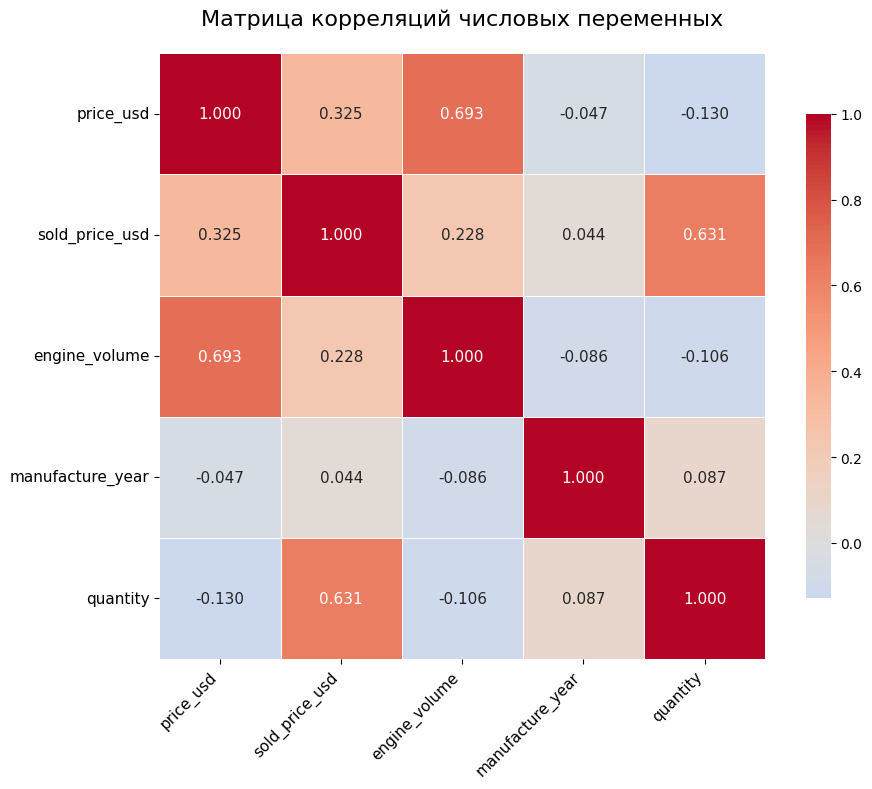

In [111]:
numeric_cols = [
    'price_usd', 'sold_price_usd', 'engine_volume',
    'manufacture_year', 'quantity'
]

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 11})
plt.title('Матрица корреляций числовых переменных',
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Сильная положительная корреляция (0.693) наблюдается между ценой автомобиля (price_usd) и объёмом двигателя (engine_volume). Это соответствует рыночной логике: автомобили с более мощными (и, как правило, более технологичными) двигателями стоят дороже. А также  связь (0.631) выявлена между итоговой стоимостью (sold_price_usd) и количеством (quantity). Данная зависимость указывает на наличие оптовых сделок, при которых увеличение количества проданных единиц связано с ростом общей суммы продажи.

Наиболее неожиданным является практически полное отсутствие корреляции между годом выпуска автомобиля и его ценой. Коэффициенты -0.047 для исходной цены и 0.044 для продажной цены близки к нулю, что противоречит обычной рыночной практике, где новизна модели является значимым ценообразующим фактором. Это может объясняться спецификой данных — преобладанием автомобилей практически одного года.



Теперь построим диаграмму рассеяния для визуального анализа связи между признаками, что позволит выявить основные тренды и аномальные значения в данных.

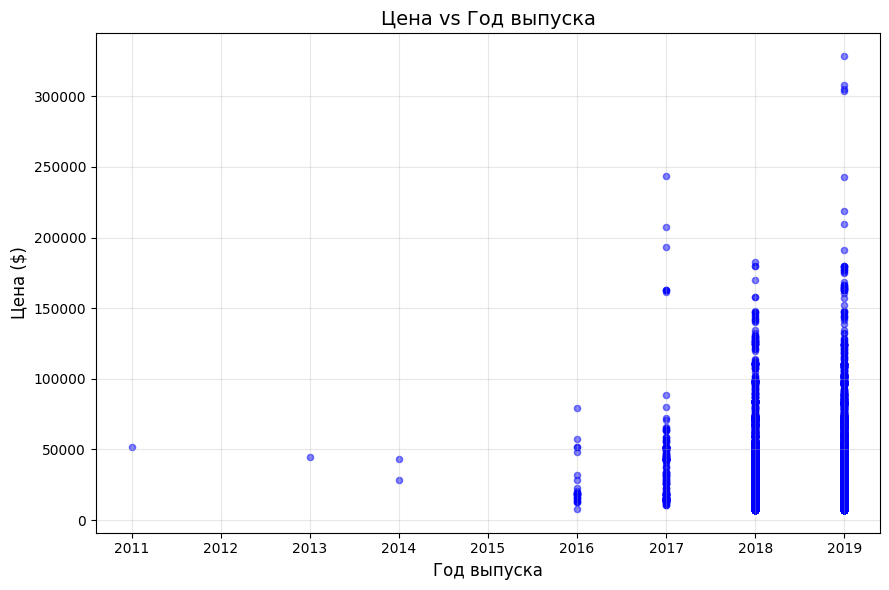

In [112]:
plt.figure(figsize=(9, 6))
plt.scatter(df['manufacture_year'], df['price_usd'], alpha=0.5, s=20, color='blue')
plt.title('Цена vs Год выпуска', fontsize=14)
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Цена ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Основной тренд заключается в отсутствии явной прямой зависимости между годом выпуска автомобиля и его ценой. Точки на диаграмме расположены хаотично, не формируя четкого восходящего или нисходящего паттерна. Однако при внимательном рассмотрении можно отметить, что более новые автомобили (справа на графике) демонстрируют в целом более широкий разброс цен, вплоть до экстремально высоких значений.

Главной аномалией является наличие немногочисленных, но крайне дорогих автомобилей (с ценой, существенно превышающей средний уровень). Скорее всего, это автомобили премиум или люкс сегмента.

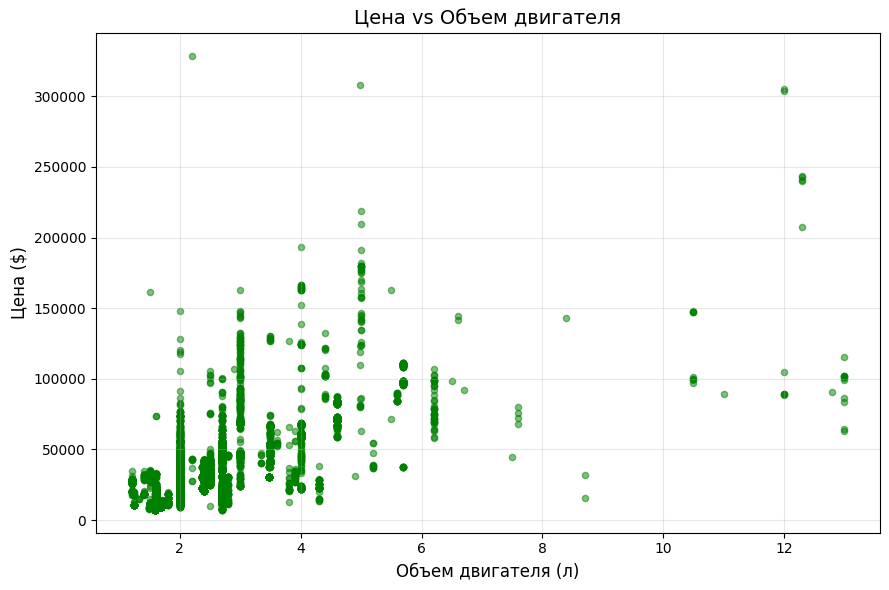

In [113]:
plt.figure(figsize=(9, 6))
plt.scatter(df['engine_volume'], df['price_usd'], alpha=0.5, s=20, color='green')
plt.title('Цена vs Объем двигателя', fontsize=14)
plt.xlabel('Объем двигателя (л)', fontsize=12)
plt.ylabel('Цена ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График рассеяния наглядно демонстрирует сильную положительную взаимосвязь между объёмом двигателя и ценой автомобиля: с ростом объёма стоимость транспортного средства в среднем увеличивается.

Наиболее яркими аномалиями выступают единичные экземпляры с экстремальным объёмом двигателя, достигающим 10–12 литров, и запредельной ценой, превышающей 250 000 долларов.

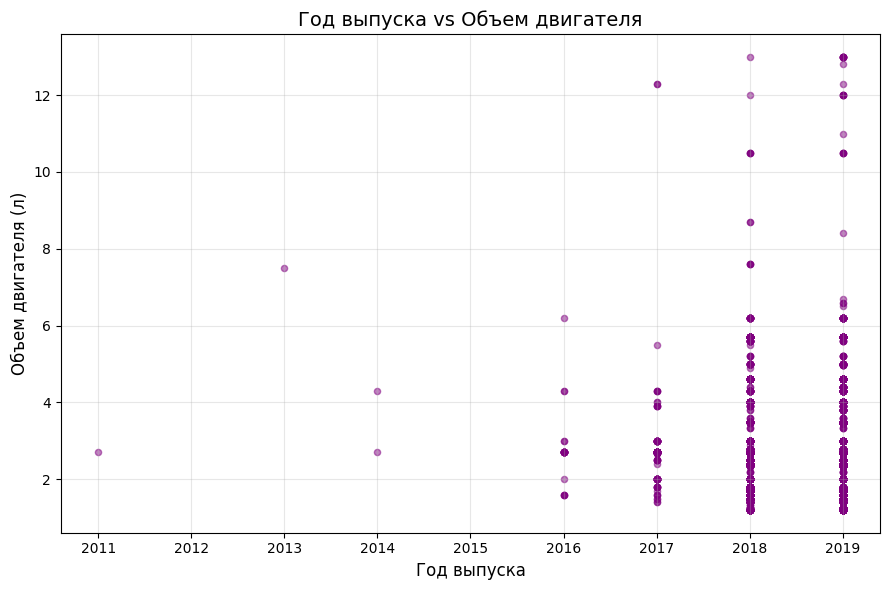

In [114]:
plt.figure(figsize=(9, 6))
plt.scatter(df['manufacture_year'], df['engine_volume'], alpha=0.5, s=20, color='purple')
plt.title('Год выпуска vs Объем двигателя', fontsize=14)
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Объем двигателя (л)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Анализ диаграммы рассеяния показывает отсутствие выраженной тенденции: объём двигателя не увеличивается и не уменьшается систематически с годом выпуска, что согласуется с ранее вычисленной слабой корреляцией (-0.086). Основная масса автомобилей сосредоточена в диапазоне до 6 литров на протяжении всего периода.



Теперь выявим временные тренды

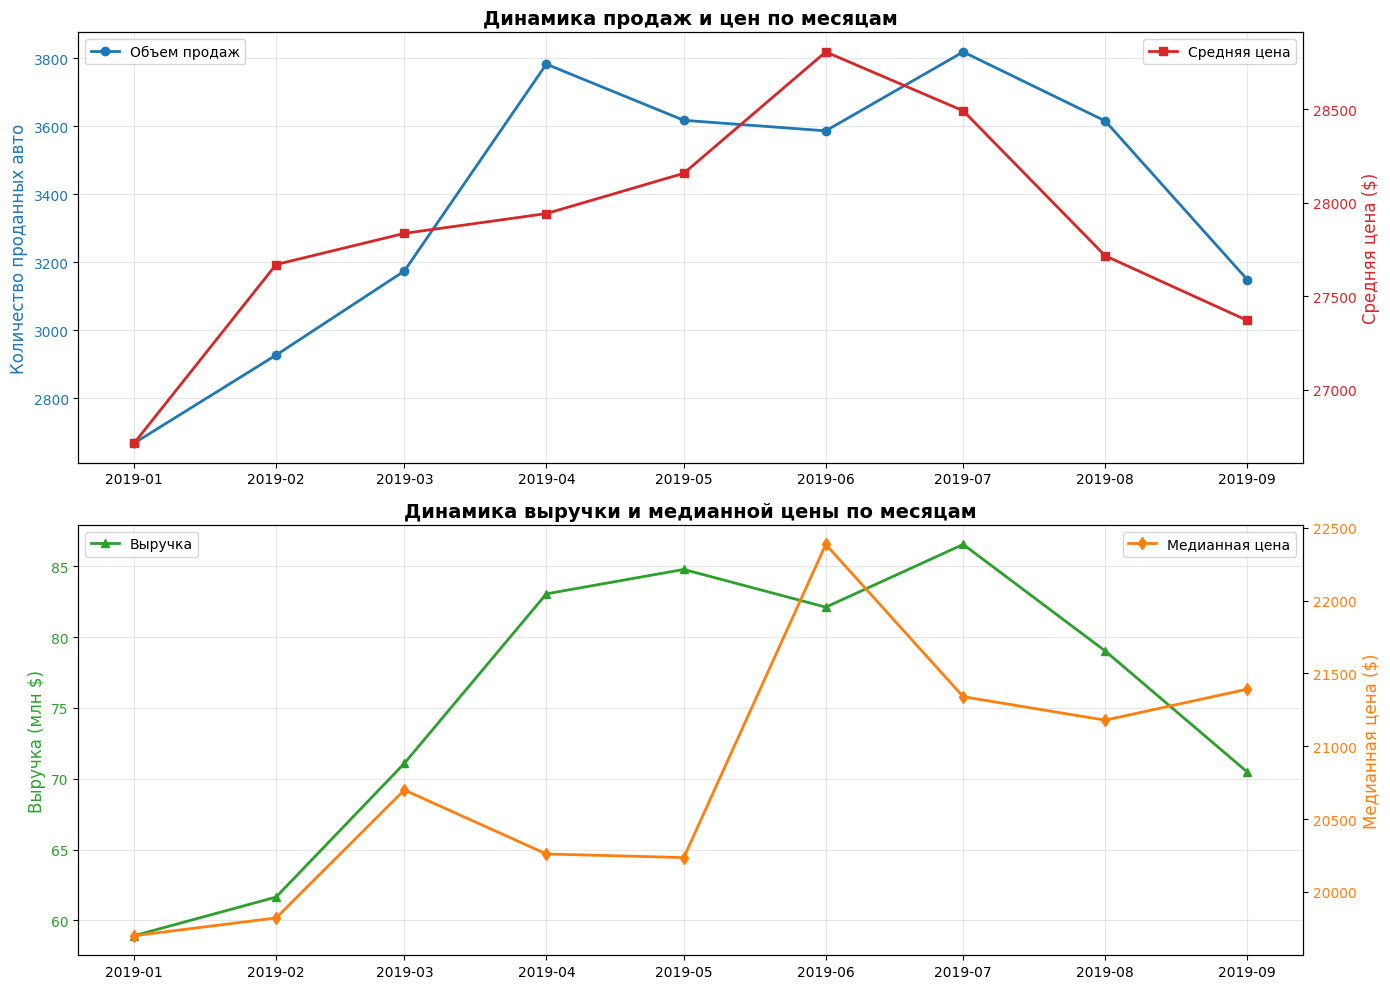

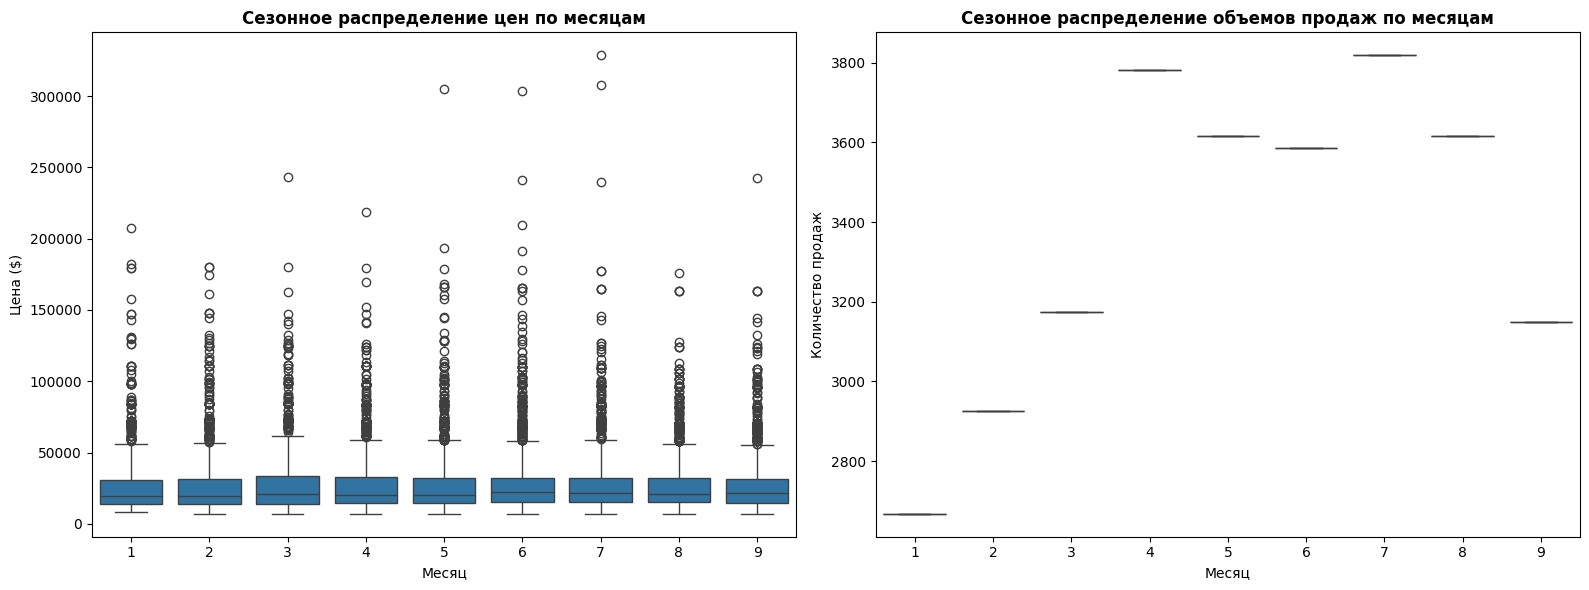

In [115]:
df['sale_month'] = df['sale_date'].dt.to_period('M').dt.to_timestamp()

monthly_trends = df.groupby('sale_month', observed=True).agg(
    total_quantity=('quantity', 'sum'),
    avg_price=('price_usd', 'mean'),
    median_price=('price_usd', 'median'),
    total_revenue=('sold_price_usd', 'sum')
).sort_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(monthly_trends.index, monthly_trends['total_quantity'],
         color='tab:blue', linewidth=2, marker='o', label='Объем продаж')
ax1.set_ylabel('Количество проданных авто', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax1_twin = ax1.twinx()
ax1_twin.plot(monthly_trends.index, monthly_trends['avg_price'],
              color='tab:red', linewidth=2, marker='s', label='Средняя цена')
ax1_twin.set_ylabel('Средняя цена ($)', color='tab:red', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='tab:red')
ax1_twin.legend(loc='upper right')

ax1.set_title('Динамика продаж и цен по месяцам', fontsize=14, fontweight='bold')

ax2.plot(monthly_trends.index, monthly_trends['total_revenue']/1e6,
         color='tab:green', linewidth=2, marker='^', label='Выручка')
ax2.set_ylabel('Выручка (млн $)', color='tab:green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

ax2_twin = ax2.twinx()
ax2_twin.plot(monthly_trends.index, monthly_trends['median_price'],
              color='tab:orange', linewidth=2, marker='d', label='Медианная цена')
ax2_twin.set_ylabel('Медианная цена ($)', color='tab:orange', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='tab:orange')
ax2_twin.legend(loc='upper right')

ax2.set_title('Динамика выручки и медианной цены по месяцам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['month'] = df['sale_date'].dt.month
sns.boxplot(data=df, x='month', y='price_usd', ax=axes[0])
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Цена ($)')
axes[0].set_title('Сезонное распределение цен по месяцам', fontsize=12, fontweight='bold')

monthly_agg = df.groupby(['month', df['sale_date'].dt.year],observed=True).agg({
    'quantity': 'sum'
}).reset_index()
monthly_agg = monthly_agg.rename(columns={'sale_date': 'year'})

sns.boxplot(data=monthly_agg, x='month', y='quantity', ax=axes[1])
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество продаж')
axes[1].set_title('Сезонное распределение объемов продаж по месяцам', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Анализ представленных графиков позволяет выявить несколько важных сезонных трендов на рынке автомобилей Казахстана за первые девять месяцев 2019 года. Продажи демонстрируют выраженную волнообразную динамику: после зимнего затишья объёмы начинают расти с марта, достигая пика в июне–июле, а затем постепенно снижаются к сентябрю. Средняя цена также расла к июню, а потом постепенно снижалась.

На графике видно, что выручка достигает максимума в июне–июле, повторяя тренд продаж, но при этом медианная цена в этот период снижается (с ~22 500 до ~20 500 $). В апреле-мае при высокой выручке, наблюдается низкая медианная цена.

### Вывод по пункту 3: Глубокая очистка и преобразование данных

Исследовастельский анализ данных выполнен в полном соответствии с планом задания

1. Изучение распределения основных переменных: цены, объёмы двигателя, год выпуска.

- Цена (`price_usd`): Распределение имеет выраженную правостороннюю асимметрию. Средняя цена (27 893) значительно превышает медианную (20 700) из-за влияния дорогих автомобилей в «хвосте» распределения. Основная масса продаж (75%) сосредоточена до 32 042, что определяет рынок как среднебюджетный. Выявлены единичные сверхдорогие предложения до 328 511, относящиеся к люксовому сегменту.

- Итоговая стоимость (`sold_price_usd`): Обнаружены экстремальные выбросы, включая сделку на 3,78 млн, что указывает на наличие крупных оптовых операций, искажающих средние показатели. Большинство розничных сделок (50%) лежат в диапазоне 17 000–42 000.

- Объём двигателя (`engine_volume`): Распределение мультимодальное с чёткими пиками популярности на 1.6, 2.0 и 2.5 литрах. 95% автомобилей имеют объём до 4.0 л, что маркирует границу массового рынка, а значения до 13.0 л относятся к спецтехнике.

- Год выпуска (`manufacture_year`): Наблюдается экстремальная концентрация: 75% автомобилей выпущены в 2019 году, а 99% — в 2018-2019. Рынок практически полностью состоит из новых автомобилей, доля подержанных менее 1%.

Рынок Казахстана сегментирован. Основной объём формируют новые, среднебюджетные автомобили с объёмом двигателя 1.6–2.7 л, в то время как статистику искажают два фактора: немногочисленные люксовые модели и крупные оптовые сделки.

2. Изучение продаж по брендам, моделям, регионам, типам топлива и коробкам передач.

- Бренды и модели: Количественно доминирует Lada (36.5% рынка), однако по выручке конкурирует Toyota, чья средняя цена (41 013) почти в 4 раза выше. Топ-3 модели (Lada Granta, Vesta, 4x4) занимают 29% рынка.

- Регион: Рынок сконцентрирован в Алматы (19.3% объёма, 26.3% выручки) и Нур-Султане (14.5% объёма). Эти города также характеризуются самыми высокими средними ценами, что указывает на концентрацию премиального сегмента.

- Топливо и трансмиссия: Абсолютно доминируют бензиновые автомобили (95.8% продаж). Автоматические коробки передач, занимая 53.8% рынка, генерируют 68.3% выручки, подтверждая их ассоциацию с более дорогими сегментами.

Казахстанский рынок демонстрирует двойственность: количественное лидерство бюджетных отечественных машин (Lada) сочетается с качественным (по выручке) вкладом международных брендов среднего и премиального ценового диапазона (Toyota, Hyundai, KIA).

3. Выявление основных трендов и аномалий.

- Корреляция: Подтверждена сильная связь между ценой и объёмом двигателя (0.693) и между итоговой стоимостью и количеством в сделке (0.631), что указывает на оптовые операции. Неожиданно слабая связь года выпуска с ценой (-0.047) объясняется преобладанием в данных новых автомобилей.

- Аномалии (IQR):

  - Цена/Стоимость: Верхние выбросы представлены дорогими автомобилями (от 58 231$) и крупными оптовыми сделками (макс. 3.78 млн$), часто связанными с коммерческим транспортом.

  - Объём двигателя: Значения >4.35 л относятся к грузовикам и автобусам (Scania, MAN).

  - Количество в сделке: 16.5% записей — оптовые продажи (от 2 автомобилей), максимальная партия — 115 единиц (Lada).

- Визуализация (Scatter plots):

  - Цена vs Год: Отсутствие чёткого тренда, но широкий разброс цен у новых авто (2018-2019), включая дорогие аномалии.

  - Цена vs Объём двигателя: Яркая положительная нелинейная зависимость.

  - Год vs Объём двигателя: Отсутствие тренда, объём двигателя не зависел от года в 2011-2019 гг.

- Временные тренды: Наблюдается сезонность. Продажи и выручка росли с марта, достигая пика в июне-июле. .

Основные аномалии данных систематичны и объяснимы — они представляют два отдельных рынка: 1) розничные продажи легковых автомобилей и 2) оптовые продажи коммерческого транспорта.


## Анализ рынка и позиции «Меркур Авто»

### Проанализируем долю рынка «Меркур Авто» в разрезе брендов, регионов, сегментов.

Для начала посчитаем долю рынка Меркур Авто, а также количество продаж у данного диллера и количество продаж на рынке.

In [116]:
mercur_mask = df['company'].str.contains('Mercur Auto', case=False, na=False)

print(f"Общее количество продаж на рынке: {len(df)}")
print(f"Количество продаж «Меркур Авто»: {mercur_mask.sum()}")
print(f"Доля рынка «Меркур Авто»: {mercur_mask.sum()/len(df)*100:.1f}%")

Общее количество продаж на рынке: 16488
Количество продаж «Меркур Авто»: 369
Доля рынка «Меркур Авто»: 2.2%


Text(0.5, 1.0, 'Доли рынка')

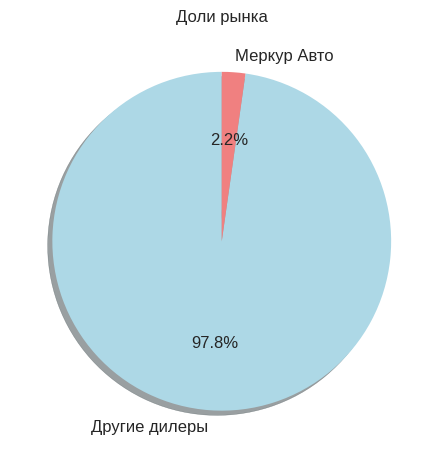

In [117]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

ax1 = plt.subplot(1, 1, 1)
labels = ['Другие дилеры', 'Меркур Авто']
sizes = [len(df) - mercur_mask.sum(), mercur_mask.sum()]
colors = ['lightblue', 'lightcoral']

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors,
                                  autopct='%1.1f%%', shadow=True, startangle=90,
                                  textprops={'fontsize': 12})
ax1.set_title(f'Доли рынка')

Несмотря на относительно небольшое абсолютное количество продаж (369 единиц), «Меркур Авто» занимает 2.2% долю автомобильного рынка Казахстана за анализируемый период. Это свидетельствует о нишевой позиции компании в конкурентной среде с общим объемом рынка в 16488 продаж

Рассмотрим долю рынка в разрезе брендов, регионов и сегментов

In [118]:
market_brands = df['brand'].value_counts()
mercur_brands = df[mercur_mask]['brand'].value_counts()

print("\nТоп-10 брендов на всем рынке:")
for i, (brand, count) in enumerate(market_brands.head(10).items(), 1):
    market_share = count / len(df) * 100
    mercur_for_brand = mercur_brands.get(brand, 0)
    mercur_share_of_brand = mercur_for_brand / count * 100 if count > 0 else 0
    print(f"{i:2d}. {brand:15} - {count:4d} продаж ({market_share:.1f}% рынка, доля Меркур в бренде: {mercur_share_of_brand:.1f}%)")

print("\nБренды «Меркур Авто»:")
for i, (brand, count) in enumerate(mercur_brands.items(), 1):
    brand_share_in_mercur = count / mercur_mask.sum() * 100
    total_brand_sales = market_brands.get(brand, 0)
    mercur_share_of_brand = count / total_brand_sales * 100 if total_brand_sales > 0 else 0
    print(f"{i:2d}. {brand:15} - {count:2d} продаж ({brand_share_in_mercur:.1f}% от продаж Меркур, {mercur_share_of_brand:.1f}% доля Меркур в бренде)")


Топ-10 брендов на всем рынке:
 1. Hyundai         - 3471 продаж (21.1% рынка, доля Меркур в бренде: 0.0%)
 2. Toyota          - 2424 продаж (14.7% рынка, доля Меркур в бренде: 0.0%)
 3. Lada            - 1954 продаж (11.9% рынка, доля Меркур в бренде: 0.0%)
 4. GAZ             - 1139 продаж (6.9% рынка, доля Меркур в бренде: 0.0%)
 5. Nissan          -  993 продаж (6.0% рынка, доля Меркур в бренде: 0.0%)
 6. Kia             -  822 продаж (5.0% рынка, доля Меркур в бренде: 0.0%)
 7. UAZ             -  730 продаж (4.4% рынка, доля Меркур в бренде: 0.0%)
 8. Renault         -  549 продаж (3.3% рынка, доля Меркур в бренде: 0.0%)
 9. Lexus           -  528 продаж (3.2% рынка, доля Меркур в бренде: 0.0%)
10. Volkswagen      -  462 продаж (2.8% рынка, доля Меркур в бренде: 58.7%)

Бренды «Меркур Авто»:
 1. Volkswagen      - 271 продаж (73.4% от продаж Меркур, 58.7% доля Меркур в бренде)
 2. Porsche         - 52 продаж (14.1% от продаж Меркур, 100.0% доля Меркур в бренде)
 3. Audi            

Анализ выявил ярко выраженную брендовую специализацию автоцентра: 73.4% продаж приходится на Volkswagen, при этом компания контролирует 58.7% продаж этого бренда на рынке. Примечательно, что «Меркур Авто» является эксклюзивным дилером Porsche и Audi (100% доля в этих брендах), что говорит о стратегическом партнерстве. В то же время компания полностью отсутствует на массовых сегментах (Hyundai, Toyota, Lada), что определяет ее премиальную ориентацию.

In [119]:
market_regions = df['region'].value_counts()
mercur_regions = df[mercur_mask]['region'].value_counts()

print("\nТоп-10 регионов на всем рынке:")
for i, (region, count) in enumerate(market_regions.head(10).items(), 1):
    market_share = count / len(df) * 100
    mercur_for_region = mercur_regions.get(region, 0)
    mercur_share_of_region = mercur_for_region / count * 100 if count > 0 else 0
    print(f"{i:2d}. {region:20} - {count:4d} продаж ({market_share:.1f}% рынка, доля Меркур в регионе: {mercur_share_of_region:.1f}%)")

print("\nРегионы «Меркур Авто»:")
for i, (region, count) in enumerate(mercur_regions.items(), 1):
    region_share_in_mercur = count / mercur_mask.sum() * 100
    total_region_sales = market_regions.get(region, 0)
    mercur_share_of_region = count / total_region_sales * 100 if total_region_sales > 0 else 0
    print(f"{i:2d}. {region:20} - {count:2d} продаж ({region_share_in_mercur:.1f}% от продаж Меркур, {mercur_share_of_region:.1f}% доля Меркур в регионе)")


Топ-10 регионов на всем рынке:
 1. Алматы               - 3093 продаж (18.8% рынка, доля Меркур в регионе: 7.4%)
 2. Нур-Султан           - 2505 продаж (15.2% рынка, доля Меркур в регионе: 2.0%)
 3. Костанай             - 1195 продаж (7.2% рынка, доля Меркур в регионе: 1.0%)
 4. Караганда            - 1189 продаж (7.2% рынка, доля Меркур в регионе: 1.8%)
 5. Шымкент              - 1134 продаж (6.9% рынка, доля Меркур в регионе: 0.0%)
 6. Атырау               - 1103 продаж (6.7% рынка, доля Меркур в регионе: 3.7%)
 7. Уральск              -  900 продаж (5.5% рынка, доля Меркур в регионе: 1.6%)
 8. Актобе               -  878 продаж (5.3% рынка, доля Меркур в регионе: 0.0%)
 9. Усть-Каменогорск     -  822 продаж (5.0% рынка, доля Меркур в регионе: 0.0%)
10. Павлодар             -  777 продаж (4.7% рынка, доля Меркур в регионе: 0.0%)

Регионы «Меркур Авто»:
 1. Алматы               - 230 продаж (62.3% от продаж Меркур, 7.4% доля Меркур в регионе)
 2. Нур-Султан           - 51 продаж (13.

Географически «Меркур Авто» демонстрирует высокую концентрацию в крупнейших городах: 62.3% продаж приходится на Алматы, где компания занимает 7.4% долю рынка. Второй по значимости регион - Нур-Султан (13.8% продаж). Важно отметить присутствие в нефтегазовом регионе Атырау (11.1% продаж, 3.7% доли рынка). Отмечается слабое присутствие в перспективных регионах с высоким рыночным потенциалом, таких как Костанай, Караганда и Шымкент.

In [120]:
market_segments = df['segmentation_2013'].value_counts()
mercur_segments = df[mercur_mask]['segmentation_2013'].value_counts()

print("\nСтруктура рынка по сегментам:")
for segment, count in market_segments.items():
    market_share = count / len(df) * 100
    mercur_for_segment = mercur_segments.get(segment, 0)
    mercur_share_of_segment = mercur_for_segment / count * 100 if count > 0 else 0
    print(f"- {segment:15} - {count:4d} продаж ({market_share:.1f}% рынка, доля Меркур в сегменте: {mercur_share_of_segment:.1f}%)")

print("\nСегменты «Меркур Авто»:")
for segment, count in mercur_segments.items():
    segment_share_in_mercur = count / mercur_mask.sum() * 100
    total_segment_sales = market_segments.get(segment, 0)
    mercur_share_of_segment = count / total_segment_sales * 100 if total_segment_sales > 0 else 0
    print(f"- {segment:15} - {count:2d} продаж ({segment_share_in_mercur:.1f}% от Меркур, {mercur_share_of_segment:.1f}% доля Меркур в сегменте)")


Структура рынка по сегментам:
- Внедорожники    - 7894 продаж (47.9% рынка, доля Меркур в сегменте: 1.8%)
- Легковые автомобили - 5718 продаж (34.7% рынка, доля Меркур в сегменте: 3.8%)
- Коммерческие автомобили - 2213 продаж (13.4% рынка, доля Меркур в сегменте: 0.1%)
- Минивэны        -  368 продаж (2.2% рынка, доля Меркур в сегменте: 1.4%)
- Пикапы          -  295 продаж (1.8% рынка, доля Меркур в сегменте: 0.3%)

Сегменты «Меркур Авто»:
- Легковые автомобили - 218 продаж (59.1% от Меркур, 3.8% доля Меркур в сегменте)
- Внедорожники    - 143 продаж (38.8% от Меркур, 1.8% доля Меркур в сегменте)
- Минивэны        -  5 продаж (1.4% от Меркур, 1.4% доля Меркур в сегменте)
- Коммерческие автомобили -  2 продаж (0.5% от Меркур, 0.1% доля Меркур в сегменте)
- Пикапы          -  1 продаж (0.3% от Меркур, 0.3% доля Меркур в сегменте)


Структура продаж по сегментам показывает фокус на легковых автомобилях (59.1% продаж «Меркур Авто» против 34.7% на рынке). В то время как рынок в целом ориентирован на внедорожники (47.9%). Компания имеет умеренное присутствие во внедорожниках (38.8% продаж) и практически отсутствует в коммерческом транспорте (0.5% продаж), что соответствует ее премиальному позиционированию.

Таким образом, «Меркур Авто» позиционируется как специализированный дилер премиальных европейских брендов с географической концентрацией в крупнейших городах и смещением в сторону сегмента легковых автомобилей, что определяет как конкурентные преимущества, так и ограничения для дальнейшего роста.

### Сравним основные показатели автоцентра (средний чек, структура продаж) с общерыночными.

Посчитаем средний и медианный чек для Меркур Авто и рынка в целом. Сравним их.

In [121]:
mercur_mask = df['company'].str.contains('Mercur Auto', case=False, na=False)
df_mercur = df[mercur_mask]
df_market = df

market_avg_price = df_market['sold_price_usd'].mean()
mercur_avg_price = df_mercur['sold_price_usd'].mean()

market_median_price = df_market['sold_price_usd'].median()
mercur_median_price = df_mercur['sold_price_usd'].median()

print(f"Средний чек по всему рынку: {market_avg_price:,.0f} USD")
print(f"Средний чек «Меркур Авто»: {mercur_avg_price:,.0f} USD")
print(f"Разница: {mercur_avg_price - market_avg_price:,.0f} USD ({((mercur_avg_price / market_avg_price) - 1) * 100:+.1f}%)")

print(f"\nМедианный чек по рынку: {market_median_price:,.0f} USD")
print(f"Медианный чек «Меркур Авто»: {mercur_median_price:,.0f} USD")
print(f"Разница: {mercur_median_price - market_median_price:,.0f} USD ({((mercur_median_price / market_median_price) - 1) * 100:+.1f}%)")

Средний чек по всему рынку: 41,097 USD
Средний чек «Меркур Авто»: 39,871 USD
Разница: -1,226 USD (-3.0%)

Медианный чек по рынку: 26,249 USD
Медианный чек «Меркур Авто»: 16,657 USD
Разница: -9,592 USD (-36.5%)


Ценовой анализ выявил парадоксальную ситуацию: при премиальном позиционировании средний чек «Меркур Авто» (39,871 USD) на 3.0% ниже рыночного (41,097 USD). Однако медианная выручка значительно ниже рынка (16,657 USD против 26,249 USD, разница -36.5%), что свидетельствует о ценовой структуре с доминированием доступных моделей Volkswagen, либо отсутсвием оптовых продаж.

Посмотрим на распределение продаж всего рынка и Меркур Авто по основным критериям: бренд, страна производства, тип топлива, тип трансмиссии, тип привода, регион, область, класс и сегментация.

In [122]:
def compare_distributions(column_name):
    print(f"Структура продаж по: {column_name}")

    market_dist = df_market[column_name].value_counts(normalize=True) * 100
    mercur_dist = df_mercur[column_name].value_counts(normalize=True) * 100

    print(f"{'Значение':<35} {'Рынок':<8} {'Меркур':<8} {'Откл.':<8} {'Доля Меркур в сегм.':<12}")

    all_values = set(market_dist.index) | set(mercur_dist.index)

    for value in all_values:
        market_pct = market_dist.get(value, 0)
        mercur_pct = mercur_dist.get(value, 0)
        deviation = mercur_pct - market_pct

        market_count = len(df_market[df_market[column_name] == value])
        mercur_count = len(df_mercur[df_mercur[column_name] == value])
        segment_share = (mercur_count / market_count * 100) if market_count > 0 else 0

        print(f"{str(value):<35} {market_pct:>5.1f}%   {mercur_pct:>5.1f}%   {deviation:>+6.1f}%   {segment_share:>8.1f}%")



In [123]:
compare_distributions('brand')

Структура продаж по: brand
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
Cadillac                              0.2%     0.0%     -0.2%        0.0%
Lexus                                 3.2%     0.0%     -3.2%        0.0%
Infiniti                              0.4%     0.0%     -0.4%        0.0%
Mitsubishi                            2.3%     0.0%     -2.3%        0.0%
Renault                               3.3%     0.0%     -3.3%        0.0%
Shacman                               0.2%     0.0%     -0.2%        0.0%
Daewoo                                0.1%     0.0%     -0.1%        0.0%
Nissan                                6.0%     0.0%     -6.0%        0.0%
Mazda                                 0.6%     0.0%     -0.6%        0.0%
ANKAI                                 0.1%     0.0%     -0.1%        0.0%
Volkswagen                            2.8%    73.4%    +70.6%       58.7%
Skoda                                 2.2%     0.0%     -2.2%        0.0%
La

Анализ подтверждает высокую брендовую концентрацию: Volkswagen составляет 73.4% продаж компании против 2.8% на рынке (отклонение +70.6%). При этом компания полностью отсутствует в массовых сегментах (Hyundai, Toyota, Lada), что создает как конкурентное преимущество в специализации, так и риски диверсификации

In [124]:
compare_distributions('manufacture_country')

Структура продаж по: manufacture_country
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
RUS                                  30.4%    71.0%    +40.6%        5.2%
JPN                                  10.9%     0.0%    -10.9%        0.0%
KAZ                                  50.4%     0.0%    -50.4%        0.0%
TUR                                   1.9%     0.0%     -1.9%        0.0%
GBR                                   1.1%     0.0%     -1.1%        0.0%
DEU                                   1.6%    28.7%    +27.2%       41.4%
CHN                                   0.2%     0.0%     -0.2%        0.0%
USA                                   1.5%     0.3%     -1.2%        0.4%
SWE                                   0.1%     0.0%     -0.1%        0.0%
AUT                                   0.2%     0.0%     -0.2%        0.0%
THA                                   1.9%     0.0%     -1.9%        0.0%


Структура по странам производства показывает смещение от локального рынка: доля автомобилей из России составляет 71.0% у «Меркур Авто» против 30.4% на рынке (+40.6%), при этом немецкие автомобили (28.7% против 1.6% на рынке) формируют премиальную часть портфеля. Полное отсутствие казахстанского производства (0% против 50.4% на рынке) подчеркивает импортную ориентацию компании.

In [125]:
compare_distributions('fuel_type')

Структура продаж по: fuel_type
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
E                                     0.0%     0.0%     -0.0%        0.0%
HYB                                   0.0%     0.0%     -0.0%        0.0%
F                                    95.5%    99.7%     +4.2%        2.3%
D                                     4.4%     0.3%     -4.2%        0.1%


Компания практически полностью сфокусирована на бензиновых автомобилях (99.7% продаж против 95.5% на рынке), что соответствует премиальному позиционированию. Дизельные автомобили составляют лишь 0.3% (против 4.4% на рынке).

In [126]:
compare_distributions('transmission')

Структура продаж по: transmission
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
Автомат                              69.8%    85.9%    +16.1%        2.8%
Механика                             30.2%    14.1%    -16.1%        1.0%


Меркур Авто демонстрирует выраженное предпочтение автоматическим трансмиссиям (85.9% продаж против 69.8% на рынке, +16.1%), что соответствует ожиданиям премиальной аудитории. Доля механических коробок передач существенно ниже рыночной (14.1% против 30.2%).

In [127]:
compare_distributions('drive_type')

Структура продаж по: drive_type
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
FWD                                  25.9%    49.3%    +23.4%        4.3%
RWD                                   6.7%     0.0%     -6.7%        0.0%
4WD                                  48.0%    46.1%     -2.0%        2.1%
2WD                                  19.3%     4.6%    -14.7%        0.5%


Распределение по типам привода показывает сбалансированный подход: доля переднего привода (FWD) составляет 49.3% (против 25.9% на рынке, +23.4%), что характерно для легковых автомобилей премиум-класса. При этом сохраняется значительная доля полного привода (4WD - 46.1%), соответствующая внедорожному сегменту.

In [128]:
compare_distributions('region')

Структура продаж по: region
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
Костанай                              7.2%     3.3%     -4.0%        1.0%
Шымкент                               6.9%     0.0%     -6.9%        0.0%
Нур-Султан                           15.2%    13.8%     -1.4%        2.0%
Семей                                 1.3%     0.0%     -1.3%        0.0%
Усть-Каменогорск                      5.0%     0.0%     -5.0%        0.0%
Сарыагаш                              0.0%     0.0%     -0.0%        0.0%
Кокшетау                              2.1%     0.0%     -2.1%        0.0%
Каскелен                              0.2%     0.0%     -0.2%        0.0%
Зыряновск                             0.0%     0.0%     -0.0%        0.0%
Тараз                                 1.0%     0.0%     -1.0%        0.0%
Алматы                               18.8%    62.3%    +43.6%        7.4%
Кульсары                              0.0%     0.0%     -0.0%        0.0%
А

Географическая концентрация подтверждается: Алматы генерирует 62.3% продаж (против 18.8% на рынке, +43.6%), также есть присутствие в Атырау (11.1% продаж, доля рынка 3.7%), что может быть связано с корпоративными продажами в нефтегазовом секторе. Отсутствие в Шымкенте и Усть-Каменогорске указывает на неиспользованный потенциал.

In [129]:
compare_distributions('oblast')

Структура продаж по: oblast
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
Акмолинская Область                   2.1%     0.0%     -2.1%        0.0%
Павлодарская Область                  5.2%     0.0%     -5.2%        0.0%
Костанайская Область                  7.3%     3.3%     -4.1%        1.0%
Мангистауская Область                 4.5%     0.0%     -4.5%        0.0%
Алматинская Область                   1.5%     0.0%     -1.5%        0.0%
Экспорт Область                       1.6%     0.0%     -1.6%        0.0%
Карагандинская Область                7.2%     5.7%     -1.5%        1.8%
Атырауская Область                    6.7%    11.1%     +4.4%        3.7%
Восточно-Казахстанская Область        6.4%     0.0%     -6.4%        0.0%
Южно-Казахстанская Область            6.9%     0.0%     -6.9%        0.0%
Г.Нур-Султан                         15.2%    13.8%     -1.4%        2.0%
Актюбинская Область                   5.3%     0.0%     -5.3%        0.0%
Г

Анализ по областям подтверждает урбанистический фокус: на города Алматы и Нур-Султан приходится 76.1% продаж компании. Присутствие в Атырауской (11.1%) и Западно-Казахстанской (3.8%) областях соответствует стратегии работы с регионами с высоким экономическим потенциалом.

In [130]:
compare_distributions('class_2013')

Структура продаж по: class_2013
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
D класс                               6.6%     0.5%     -6.0%        0.2%
Компактные SUV                       18.2%    17.6%     -0.6%        2.2%
Развозные автомобили                  1.5%     0.0%     -1.5%        0.0%
C класс                               7.1%     1.4%     -5.7%        0.4%
Среднетоннажные грузовики             0.3%     0.0%     -0.3%        0.0%
Полноразмерный Минивэн                0.2%     1.4%     +1.1%       12.5%
F класс                               0.2%     3.3%     +3.0%       31.6%
Компактвэн                            2.0%     0.0%     -2.0%        0.0%
Полноразмерные SUV                    7.4%    18.2%    +10.8%        5.5%
Спортивные автомобили                 0.1%     0.5%     +0.5%       20.0%
Крупнотоннажные грузовики             2.5%     0.0%     -2.5%        0.0%
B класс                              19.5%    50.9%    +31.4%        5.

Структура по классам показывает смещение к компактным и средним сегментам: B-класс составляет 50.9% продаж (против 19.5% на рынке, +31.4%), что соответствует популярным моделям Volkswagen. Присутствие в F-классе (3.3% против 0.2% на рынке) и спортивных автомобилях (0.5% против 0.1%) подтверждает премиальную составляющую

In [131]:
compare_distributions('segmentation_2013')

Структура продаж по: segmentation_2013
Значение                            Рынок    Меркур   Откл.    Доля Меркур в сегм.
Минивэны                              2.2%     1.4%     -0.9%        1.4%
Пикапы                                1.8%     0.3%     -1.5%        0.3%
Легковые автомобили                  34.7%    59.1%    +24.4%        3.8%
Коммерческие автомобили              13.4%     0.5%    -12.9%        0.1%
Внедорожники                         47.9%    38.8%     -9.1%        1.8%


Детальный анализ по сегментам подтверждает стратегический выбор: фокус на легковые автомобили (59.1% против 34.7% на рынке, +24.4%) с умеренным присутствием во внедорожниках (38.8% против 47.9%). Практически полное отсутствие в коммерческом транспорте (0.5% против 13.4%) и пикапах (0.3% против 1.8%) определяет четкие границы специализации.

### Определим сильные и слабые стороны позиционирования «Меркур Авто».

На основе проведённого анализа рынка и позиции «Меркур Авто» (анализ доли рынка Меркур Авто в разрезе брендов, регионов, сегментов; сравнение основных показателей автоцентра (средний чек, структура продаж) с общерыночними) можно выделить следующие сильные и слабые стороны её рыночного позиционирования:


1. Брендовое позиционирование

Сильная сторона: Чёткая премиальная и эксклюзивная специализация. Компания является ключевым игроком для трёх европейских брендов, занимая уникальные рыночные ниши:
- Volkswagen: Контролирует 58.7% продаж бренда на рынке, делая его своим флагманом (73.4% собственных продаж).
- Porsche и Audi: Является эксклюзивным дилером с 100% долей рынка по этим брендам, что формирует имидж абсолютного премиума и защищает от прямой конкуренции внутри бренда.

Слабая сторона: Крайне высокая зависимость от одного бренда (Volkswagen) и отсутствие диверсификации. Компания полностью исключена из массовых сегментов (Hyundai, Toyota, Lada, Kia), на которые суммарно приходится ~58% рынка, что ограничивает потенциальную клиентскую базу и усиливает риски при изменении партнёрской политики или модельного ряда Volkswagen.

2. Географическое покрытие и региональная стратегия

Сильная сторона: Концентрация на наиболее ёмких и платёжеспособных рынках. Компания эффективно присутствует в финансово-экономических центрах страны:
- Алматы: Генерирует 62.3% продаж при высокой доле рынка в регионе (7.4%).
- Атырау: Демонстрирует сильное присутствие (11.1% продаж, доля 3.7%), успешно работая с корпоративным сегментом нефтегазовой отрасли.

Слабая сторона: Критически низкое присутствие или полное отсутствие в крупных регионах с высоким рыночным потенциалом. Не охвачены такие ключевые города, как: Шымкент (6.9% рынка), Актобе (5.3%), Усть-Каменогорск (5.0%) и Павлодар (4.7%), где доля «Меркур Авто» равна нулю. Это указывает на значительные неиспользованные возможности для роста.

3. Продуктовая и сегментная стратегия

Сильная сторона: Доминирование в целевом сегменте легковых автомобилей (59.1% продаж против 34.7% на рынке) с акцентом на B-класс (50.9% продаж), что соответствует спросу на премиальные, но практичные городские модели. Наличие уникальных для рынка позиций (Porsche, Audi, F-класс) укрепляет имидж.

Слабая сторона: Недостаточное проникновение в крупнейший рыночный сегмент — внедорожники (38.8% против 47.9% на рынке), особенно в субкомпактных и среднеразмерных SUV, где рыночный спрос максимален. Продуктовый ассортимент слабо представлен в нишах пикапов и коммерческого транспорта.

4. Ценовое позиционирование и клиентская ценность

Сильная сторона: Предложение преимущественно автоматических трансмиссий (85.9% против 69.8% на рынке) и бензиновых двигателей соответствует ожиданиям комфорта и экологическим трендам премиальной аудитории. Средний чек близок к рыночному, что говорит о сохранении конкурентоспособности.

Слабая сторона: Значительное отставание медианного чека (-36.5% к рынку) указывает на серьёзный перекос в сторону продаж наиболее доступных моделей (вероятно, Volkswagen), что может подрывать восприятие компании как премиального дилера.

5. Структура поставок и клиентские предпочтения

Сильная сторона: Сильная ориентация на импортные (немецкие) и российские автомобили (71.0% продаж), что может соответствовать логистическим и складским компетенциям компании. Высокая доля переднего привода (FWD) говорит об оптимизации под городские условия эксплуатации.

Слабая сторона: Полное отсутствие в сегменте автомобилей казахстанской сборки (0% против 50.4% на рынке) является стратегическим упущением, отсекающим компанию от значительной доли госзакупок, клиентов, ориентированных на локализованное производство.

Таким образом, позиционирование компании можно охарактеризовать как сильное в нише, но ограниченное для масштабирования. Для устойчивого роста «Меркур Авто» необходимо решить дилемму между сохранением премиальной специализации и расширением как географического, так и продуктового охвата.